# Exploratory Data Analysis

# 1. Data Context

## Questions we are asking:
* Where does the data come from, who collected it, and how?
* How were participants and measurements sampled, and what biases follow from that?
* What do the features (columns) mean?

## 1.1 Data source and provenance
* **Publisher:** [Welltory](https://welltory.com), an app that measures stress and energy from heart rate variability. The team released the data openly on GitHub (`Welltory/hrv-covid19`) as part of an open COVID-19 research project run in **2020**.
* **Who collected it and how:** Welltory app users who had COVID-19 (positive status or symptoms) opted in through an in-app consent form. The consent file in the repository says participation was voluntary and unpaid, asked for roughly 2 months of daily measurements plus symptom surveys, and gave free app access during the study.
* **Instruments:**
  * On-demand HRV measurements were taken either with a Bluetooth chest-strap heart rate monitor or with the **smartphone camera** (photoplethysmography, PPG: the finger covers the camera and flash).
  * Passive data (heart rate, steps, sleep, SpO2) was synced from wearables such as Apple Watch and Garmin through Apple Health or Google Fit.
  * Surveys were answered in the app.
* **Privacy and license:** the data is anonymized: `user_code` is a random hash, with no names or e-mails. It is released under **CC0 1.0** (public domain). The data was used in Welltory's preprint *"Heart Rate Variability as a Prospective Predictor of Early COVID-19 Symptoms"* and several peer-reviewed studies.

## 1.2 Sampling: who and what is in the data
This is **not a random sample**; it is a self-selected convenience sample of app users.
* **Unit of observation:** differs by table. In `hrv_measurements`, one row is one spot recording of about 100 heartbeats (≈1.5 minutes). The user starts it whenever they choose, not on a fixed schedule.
* **Time period:** 2019-12-31 to 2020-06-19, concentrated in April–May 2020 (the first COVID-19 wave).
* **Consequences for analysis:**
  * *Selection bias:* participants are smartphone-owning, health-engaged Welltory users, mostly from Russia and the US.
  * *Engagement bias:* a few very active users generate a large share of the rows.
  * *No healthy control group:* only people who reported COVID-19 took part.
  * *Unconfirmed illness status:* COVID-19 status and onset are self-reported, with no lab confirmation in these tables.

## 1.3 What the features mean
Information gathered from the repository's `datatypes.md` and the HRV literature (Task Force of the ESC/NASPE, 1996; Shaffer & Ginsberg, 2017).

**`hrv_measurements`** (one row per recording)

| Column | Meaning | Unit / scale |
|---|---|---|
| `user_code` | anonymized user id (foreign key to `participants`) | hash |
| `rr_code` | unique recording id (primary key) | hash |
| `measurement_datetime`, `time_of_day` | timestamp and the app's label (morning / day / evening / night) | datetime, category |
| `bpm` | average heart rate during the recording | beats/min |
| `meanrr` | mean RR interval (time between successive beats) | ms |
| `sdnn` | standard deviation of RR intervals: **overall variability** | ms |
| `rmssd` | root mean square of successive RR differences: **beat-to-beat (parasympathetic/vagal) variability**, the most common short-term HRV index. Higher values usually mean better recovery; values drop with stress, fever and infection. | ms |
| `pnn50` | % of successive RR intervals differing by more than 50 ms (also vagal) | % |
| `mode`, `amo`, `mxdmn` | Baevsky "variation pulsometry" indices, popular in Russian HRV practice: the most frequent RR interval, the share of intervals in that modal bin, and the range (max − min) of RR intervals | see Section 5.2 for units |
| `lf`, `hf`, `vlf`, `total_power` | spectral power in the low- (0.04–0.15 Hz), high- (0.15–0.4 Hz) and very-low-frequency bands. HF ≈ respiratory/vagal; LF mixes sympathetic, vagal and baroreflex activity. | ms² |
| `lfhf` | LF/HF ratio, a controversial "sympatho-vagal balance" index | ratio |
| `how_feel`, `how_mood`, `how_sleep` | self-rated physical state, mood and sleep quality after the recording | −2 (very bad) … +2 (very good) |
| `tags` | optional context tags chosen by the user (e.g. *After; Workout*, *COVID-19*) | `;`-separated text |
| `rr_data` | the **raw RR interval series** the metrics are computed from | comma-separated ms |

Note: VLF (< 0.04 Hz, i.e. cycles longer than 25 s) cannot be estimated reliably from a ~90-second recording, so `vlf` is treated with caution.

**`participants`** (one row per user): `gender` (f/m), `age_range` (10-year buckets), `city`, `country`, `height` (cm), `weight` (kg), `symptoms_onset` (self-reported date symptoms began).

**Secondary tables:**
* `heart_rate`: passive wearable heart rate readings.
* `wearables`: daily activity and vital-sign summaries.
* `sleep`: sleep sessions and stages.
* `blood_pressure`: manual BP entries and derived indices.
* `surveys`: COVID-19 symptom and health-risk questionnaires, in long format.
* `scales_description`: codebook for the survey scales.
* `weather`: daily weather at the user's city.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

# The notebook lives in week4/ and the data in data/week4/ at the repo root (data is NOT committed to git)
DATA_DIR = next((p for p in [Path("../data/week4"), Path("data/week4")] if (p / "hrv_measurements.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Download the Welltory CSVs into data/week4/ (see the instructions at the top)")
print("Reading data from:", DATA_DIR.resolve())

# Load all 9 tables
TABLES = ["participants", "hrv_measurements", "heart_rate", "blood_pressure", "sleep",
          "surveys", "wearables", "weather", "scales_description"]
raw = {name: pd.read_csv(DATA_DIR / f"{name}.csv") for name in TABLES}
participants_raw = raw["participants"]
hrv_raw = raw["hrv_measurements"]

# Natural orderings used throughout
order_tod = ["morning", "day", "evening", "night"]
age_order = sorted(participants_raw["age_range"].unique())

Reading data from: C:\study\AIPI 510\aipi510-fall26\data\week4


# 2. Choosing What to Explore

## Questions we are asking:
* Which of the 9 tables have enough coverage and quality to be worth exploring in depth?
* Which tables can be left out, and why?

Not every table deserves a deep dive. I first build a lightweight **data profile of all 9 tables**: size, user coverage, missingness, duplicates and date range. I then decide where to spend effort based on that evidence.

In [2]:
# Table Profile
print("Table Profile")
print("-------------")
DATE_COLS = {"hrv_measurements": "measurement_datetime", "heart_rate": "datetime", "blood_pressure": "measurement_datetime",
             "sleep": "day", "surveys": "created_at", "wearables": "day", "weather": "day"}
all_users = set(participants_raw["user_code"])

rows = []
for name, table in raw.items():
    date_col = DATE_COLS.get(name)
    dates = pd.to_datetime(table[date_col]) if date_col else None
    has_users = "user_code" in table
    rows.append({
        "table": name,
        "rows": table.shape[0],
        "columns": table.shape[1],
        "users": table["user_code"].nunique() if has_users else np.nan,
        "user_coverage_%": round(100 * table["user_code"].nunique() / len(all_users), 1) if has_users else np.nan,
        "overall_missing_%": round(100 * table.isna().mean().mean(), 1),
        "worst_column_missing_%": round(100 * table.isna().mean().max(), 1),
        "duplicate_rows": int(table.duplicated().sum()),
        "first_date": dates.min().date() if date_col else None,
        "last_date": dates.max().date() if date_col else None,
    })
table_profile = pd.DataFrame(rows).set_index("table")
table_profile

Table Profile
-------------


,rows,columns,users,user_coverage_%,overall_missing_%,worst_column_missing_%,duplicate_rows,first_date,last_date
table,,,,,,,,,
participants,185,8,185.0,100.0,3.9,20.5,0,None,None
hrv_measurements,3245,22,185.0,100.0,4.0,54.8,0,2019-12-31,2020-06-19
heart_rate,523783,4,79.0,42.7,0.0,0.0,0,2020-01-01,2020-06-19
blood_pressure,721,8,28.0,15.1,29.5,60.7,0,2019-12-31,2020-06-19
sleep,425,12,10.0,5.4,56.3,98.4,0,2019-12-31,2020-06-17
surveys,2259,5,111.0,60.0,0.0,0.0,0,2020-01-15,2020-05-28
wearables,3098,18,79.0,42.7,48.2,98.7,0,2020-01-01,2020-06-19
weather,1717,7,104.0,56.2,0.0,0.0,0,2020-01-01,2020-06-19
scales_description,148,4,NaN,NaN,0.0,0.0,0,None,None


## Interpretation

`participants` has one row per user (185), and only `hrv_measurements` covers *all* of them. The other tables cover between 5% and 60% of users, and several are dominated by device-dependent missingness.

| Table | Decision | Rationale |
|---|---|---|
| `hrv_measurements` | **Explore in depth** | The only measurement table with 100% user coverage. It contains the HRV features at the core of the COVID-19 research question, and its raw RR intervals (`rr_data`) let me *verify* the derived metrics. |
| `participants` | **Explore in depth** | Demographic context, plus `symptoms_onset`, which is needed to place each recording on an illness timeline. |
| `scales_description` | Lookup only | It is a codebook, not observations. |
| `heart_rate` | Profiled, used as a duplicate-handling contrast in Section 5.1 | 524k passive readings from only 79 users (43%), with thousands of conflicting duplicate timestamps. It would need resampling to a common grid, and passive wearable HR is a different construct from a controlled HRV recording. |
| `wearables` | Profiled only | Only 79 users; most columns are 33–99% missing because each device records different fields (e.g. SpO2 and body temperature only on some watches). |
| `surveys` | Profiled only | 111 users in long format. It is valuable as *labels* for a later modeling task, but the per-recording self-reports (`how_feel`, `tags`) already cover well-being for every user. |
| `weather` | Not explored | An environmental covariate keyed by city and day, not a property of the participant. |
| `blood_pressure` | Not explored | Only 28 users (15%), and its derived indices are ~59% missing. |
| `sleep` | Not explored | Only 10 users (5%), too few to generalize; sleep-stage columns are >93% missing. |

# 3. Data Structure

## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?
* Which columns identify a record and link the tables (keys)?

In [3]:
# Data Structure
for name, table in [("participants", participants_raw), ("hrv_measurements", hrv_raw)]:
    title = f"Data Structure: {name}"
    print(f"\n{title}\n{'-' * len(title)}")
    print(f"Dimensions: {table.shape}")
    print(f"Data Types:\n{table.dtypes}")
    print(f"Missing Values:\n{table.isnull().sum()}")


Data Structure: participants
----------------------------
Dimensions: (185, 8)
Data Types:
user_code             str
gender                str
age_range             str
city                  str
country               str
height            float64
weight            float64
symptoms_onset        str
dtype: object
Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64

Data Structure: hrv_measurements
--------------------------------
Dimensions: (3245, 22)
Data Types:
user_code                   str
rr_code                     str
measurement_datetime        str
time_of_day                 str
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf 

In [4]:
# Keys, cardinality and the stored RR-interval series
print("Unique values per column (hrv_measurements):")
print(hrv_raw.nunique().sort_values())

rr_counts = hrv_raw["rr_data"].str.count(",") + 1
print("\nRR intervals stored per recording (count of recordings):")
print(rr_counts.value_counts().sort_index())

print("\nprimary keys unique -> participants.user_code:", participants_raw["user_code"].is_unique,
      "| hrv_measurements.rr_code:", hrv_raw["rr_code"].is_unique)
print("users in hrv but not in participants:", len(set(hrv_raw["user_code"]) - set(participants_raw["user_code"])),
      "| participants without any hrv row:", len(set(participants_raw["user_code"]) - set(hrv_raw["user_code"])))
hrv_raw.drop(columns="rr_data").head()

Unique values per column (hrv_measurements):
time_of_day                4
how_sleep                  5
how_mood                   5
how_feel                   5
mode                      18
mxdmn                     66
bpm                       71
amo                       87
pnn50                    146
user_code                185
tags                    1187
vlf                     1283
hf                      1524
lf                      1559
lfhf                    1982
total_power             2275
meanrr                  3134
rmssd                   3174
sdnn                    3180
measurement_datetime    3241
rr_code                 3245
rr_data                 3245
dtype: int64

RR intervals stored per recording (count of recordings):
rr_data
100    3097
101       3
102       2
104       1
300     142
Name: count, dtype: int64

primary keys unique -> participants.user_code: True | hrv_measurements.rr_code: True
users in hrv but not in participants: 0 | participants without any

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN


In [5]:
# How are missing values represented?
def missing_report(df):
    out = pd.DataFrame({"n_missing": df.isna().sum(), "pct_missing": (100 * df.isna().mean()).round(1)})
    return out[out["n_missing"] > 0].sort_values("pct_missing", ascending=False)

print("participants:\n", missing_report(participants_raw))
print("\nhrv_measurements:\n", missing_report(hrv_raw))

# Missing values can also hide behind placeholder strings or impossible numbers
sentinels = {"", "none", "null", "nan", "n/a", "na", "-", "unknown", "0"}
disguised = {col: int(table[col].dropna().astype(str).str.strip().str.lower().isin(sentinels).sum())
             for table, cols in [(participants_raw, ["gender", "age_range", "city", "country", "symptoms_onset"]),
                                 (hrv_raw, ["time_of_day", "tags"])]
             for col in cols}
print("\nplaceholder strings posing as real values:", disguised)
print("zero or negative height/weight values:", int((participants_raw[["height", "weight"]] <= 0).sum().sum()))

participants:
                 n_missing  pct_missing
symptoms_onset         38         20.5
city                   12          6.5
country                 6          3.2
height                  2          1.1

hrv_measurements:
            n_missing  pct_missing
how_sleep       1779         54.8
tags            1044         32.2

placeholder strings posing as real values: {'gender': 0, 'age_range': 0, 'city': 0, 'country': 0, 'symptoms_onset': 0, 'time_of_day': 0, 'tags': 0}
zero or negative height/weight values: 0


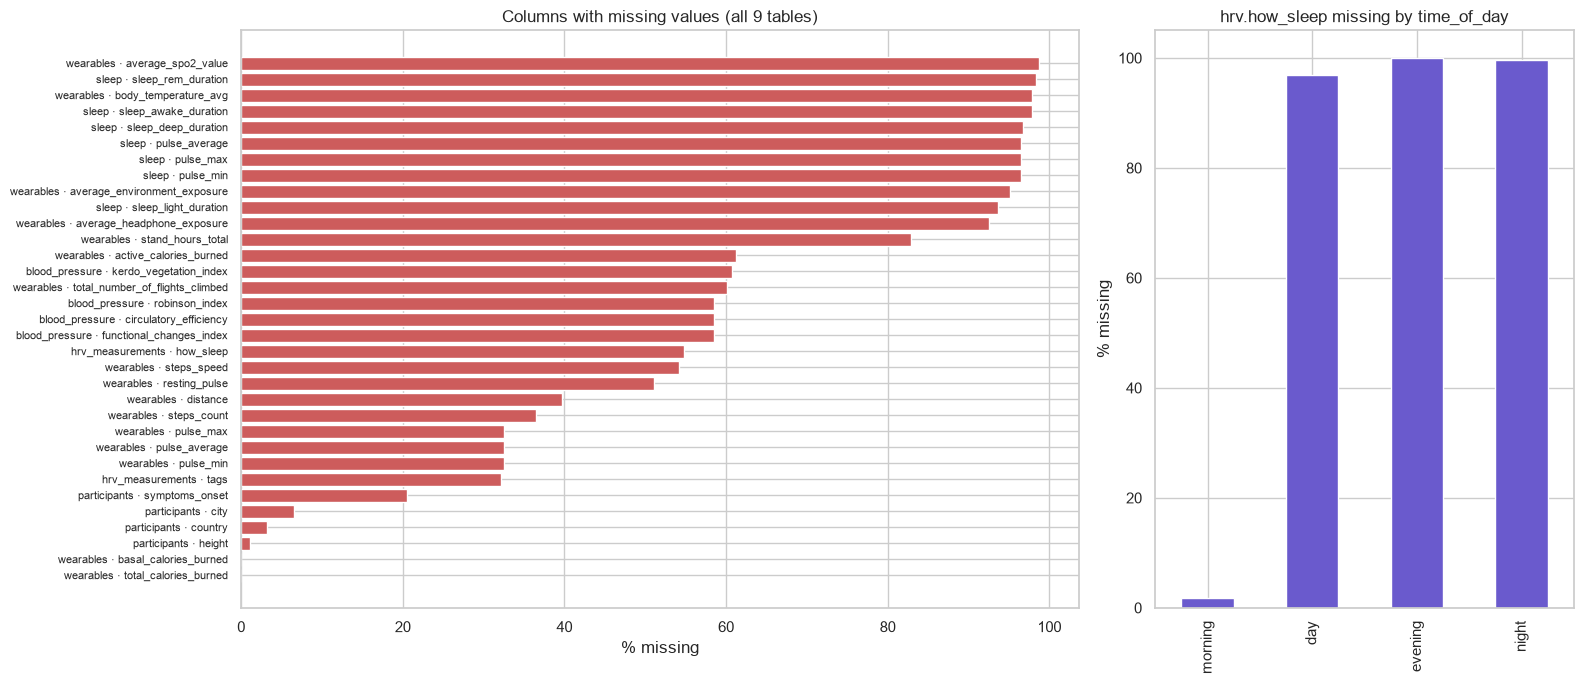

% how_sleep missing by time_of_day: {'morning': 1.8, 'day': 96.9, 'evening': 100.0, 'night': 99.6}
% tags missing by time_of_day: {'day': 32.1, 'evening': 33.4, 'morning': 36.9, 'night': 3.3}


In [6]:
miss = pd.concat({name: table.isna().mean() * 100 for name, table in raw.items()}).reset_index()
miss.columns = ["table", "column", "pct"]
miss = miss[miss["pct"] > 0].sort_values("pct")
sleep_missing = hrv_raw["how_sleep"].isna().groupby(hrv_raw["time_of_day"]).mean().reindex(order_tod) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [2, 1]})
axes[0].barh(miss["table"] + " · " + miss["column"], miss["pct"], color="indianred")
axes[0].set(title="Columns with missing values (all 9 tables)", xlabel="% missing")
axes[0].tick_params(axis="y", labelsize=8)
sleep_missing.plot(kind="bar", ax=axes[1], color="slateblue")
axes[1].set(title="hrv.how_sleep missing by time_of_day", ylabel="% missing", xlabel="")
plt.tight_layout()
plt.show()

print("% how_sleep missing by time_of_day:", sleep_missing.round(1).to_dict())
print("% tags missing by time_of_day:", (hrv_raw["tags"].isna().groupby(hrv_raw["time_of_day"]).mean() * 100).round(1).to_dict())

## Interpretation

#### Dimensions
* `participants` has 185 rows × 8 columns, one row per user.
* `hrv_measurements` has 3,245 rows × 22 columns, one row per recording.
* Each recording stores a short RR series: 3,097 recordings store exactly 100 intervals (≈ 100 × 0.84 s ≈ 1.4 minutes) and 142 store 300. Every recording is therefore a **short-term recording**, which limits how reliably the slow frequency bands (VLF) can be estimated.

#### Data Types
* **Numerical:** the HRV metrics (`bpm` is an integer; the rest are floats), plus `height` and `weight`.
* **Ordinal codes stored as numbers:** `how_feel`, `how_mood` and `how_sleep` are integer answers on a −2…+2 scale. They are ordinal categories rather than continuous measurements. `how_sleep` is a float only because it contains NaN.
* **Categorical:** `gender`, `age_range` (ordered buckets), `city`, `country`, `time_of_day`.
* **Text:** `tags` is a multi-label list, and `rr_data` is a numeric *sequence* stored as a comma-separated string.
* **Dates stored as text:** `measurement_datetime` uses ISO format, but `symptoms_onset` uses US `M/D/YYYY`. Both need explicit parsing (Sections 8.1 and 9.1).
* **Identifiers:** `user_code` and `rr_code` are hash strings and must never be used as model features.

#### Keys
* `rr_code` is unique in `hrv_measurements` (primary key).
* `user_code` is unique in `participants` (primary key) and links to `hrv_measurements` in both directions with no orphans.

#### Missing Values
* **How they are represented:** missing values are empty CSV fields, read as NaN. No placeholder strings (e.g. "unknown", "-") or zero heights/weights disguise missing values as real ones. However, Section 5.4 shows that some *non-null* values (impossible onset dates) are effectively missing.
* **`participants`:** `symptoms_onset` is missing for 38 users (20.5%), `city` for 12, `country` for 6 and `height` for 2. These are optional profile fields that users skipped.
* **`hrv_measurements`:**
  * All HRV metrics are complete, which makes sense because they are computed automatically; a missing value would mean a failed recording.
  * Only the self-report fields have gaps.
* **`how_sleep`: 54.8% missing, but by design.** It is missing for only 2% of morning recordings versus 97–100% of day, evening and night recordings. The app evidently asks "how did you sleep?" only after a morning measurement. The value is *not applicable* rather than unknown, so imputing it would invent answers to a question that was never asked.
* **`tags`: 32% missing.** Tags are optional, so a missing value means "no context reported". It is better represented as an empty tag list than as an unknown value.
* **Secondary tables:** sleep stages, SpO2, body temperature and audio exposure are more than 90% missing because only certain devices record them. This supports leaving those tables out of scope.

The handling strategy for missing values is implemented in Section 8.1.

# 4. Descriptive Statistics

## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?
* How are the categorical variables (demographics, time of day, tags) distributed?

In [7]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
hrv_numeric = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "mode", "amo", "mxdmn", "lf", "hf", "vlf", "lfhf", "total_power",
               "how_feel", "how_mood", "how_sleep"]
stats = hrv_raw[hrv_numeric]

print("Central Tendency Measures:")
print(pd.DataFrame({"mean": stats.mean(), "median": stats.median(), "mode": stats.mode().iloc[0]}).round(2))

print("\nDispersion Measures:")
print(pd.DataFrame({"std": stats.std(), "variance": stats.var(), "IQR": stats.quantile(0.75) - stats.quantile(0.25),
                    "min": stats.min(), "max": stats.max(), "range": stats.max() - stats.min()}).round(2))

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(pd.DataFrame({"skewness": stats.skew(), "kurtosis": stats.kurt()}).round(2))


Descriptive Statistics
----------------------
Central Tendency Measures:
                mean   median    mode
bpm            73.26    72.00   66.00
meanrr        839.60   829.10  791.43
sdnn           52.49    46.92   33.28
rmssd          52.81    42.87   22.42
pnn50          20.62    16.16    0.00
mode            0.84     0.82    0.82
amo            46.79    45.00   32.00
mxdmn           0.18     0.16    0.17
lf            927.04   423.00   48.00
hf           1125.04   380.00  101.00
vlf           578.23   293.00   56.00
lfhf            2.40     0.86    0.50
total_power  2630.31  1387.00  357.00
how_feel       -0.24     0.00    0.00
how_mood       -0.08     0.00    0.00
how_sleep      -0.07     0.00    0.00

Dispersion Measures:
                 std     variance      IQR     min       max     range
bpm            12.20       148.87    16.00   44.00    125.00     81.00
meanrr        137.42     18884.36   183.44  477.73   1346.74    869.01
sdnn           29.37       862.57    31.82   

In [8]:
# Categorical variables
for col in ["gender", "age_range", "country"]:
    counts = participants_raw[col].value_counts(dropna=False)
    print(f"\n{col}:")
    print(pd.concat([counts, (100 * counts / counts.sum()).round(1)], axis=1, keys=["n", "%"]).head(8))

print("\nheight / weight:")
print(participants_raw[["height", "weight"]].describe().round(1))

print("\nself-reported ratings (counts):")
print(pd.concat({c: hrv_raw[c].value_counts(dropna=False).sort_index() for c in ["how_feel", "how_mood", "how_sleep"]}, axis=1))
print("\ntime_of_day:\n", hrv_raw["time_of_day"].value_counts())

tag_counts = hrv_raw["tags"].dropna().str.split(";").explode().str.strip().value_counts()
print("\ndistinct individual tags:", tag_counts.size)
print(tag_counts.head(12))


gender:
          n     %
gender           
f       118  63.8
m        67  36.2

age_range:
            n     %
age_range          
35-44      56  30.3
45-54      51  27.6
25-34      46  24.9
18-24      16   8.6
55-64       9   4.9
65-74       7   3.8

country:
                 n     %
country                 
Russia          66  35.7
United States   60  32.4
United Kingdom  12   6.5
Ukraine          7   3.8
Brazil           6   3.2
NaN              6   3.2
Belarus          5   2.7
France           3   1.6

height / weight:
       height  weight
count   183.0   185.0
mean    170.0    77.9
std      12.4    19.6
min     132.1    43.5
25%     163.5    63.5
50%     168.0    74.3
75%     174.5    90.5
max     250.0   154.2

self-reported ratings (counts):
      how_feel  how_mood  how_sleep
-2.0     124.0      96.0         50
-1.0     857.0     471.0        238
 0.0    1975.0    2335.0        967
 1.0     237.0     272.0        180
 2.0      52.0      71.0         31
 NaN       NaN       N

## Interpretation

#### Central Tendency Measures
* **Heart rate:** `bpm` has mean 73.3 and median 72, and `meanrr` has mean 840 ms and median 829 ms. Mean ≈ median indicates roughly symmetric distributions.
* **Variability metrics:** here the mean is pulled far above the median.
  * RMSSD: mean 52.8 ms vs median 42.9 ms.
  * LF: mean 927 vs median 423 ms².
  * HF: mean 1,125 vs median 380 ms², almost 3×.

  For these metrics the **median is the more representative "typical" value**, so I summarize with medians.
* **Mode:** not informative for continuous metrics, where almost every value is unique. It is meaningful for discrete columns: all three self-ratings have mode and median 0 (neutral), while `how_feel` averages slightly negative (−0.24), which fits a population that is ill.

#### Dispersion Measures
* **`bpm`:** standard deviation 12.2 bpm, range 44–125 bpm, a physiologically plausible spread.
* **RMSSD:** ranges from 6.3 to 310.8 ms (a factor of ~50), and its standard deviation (39.4 ms) is larger than its IQR (33.5 ms), a sign that a few extreme values inflate the spread.
* **Spectral powers:** span several orders of magnitude (HF 4–33,490 ms², LF/HF 0.03–105.6), so their variance is dominated by a handful of recordings.
* **`mode` and `mxdmn`:** range only 0.48–1.32 and 0.03–0.79. Next to `meanrr` (≈ 840 ms), they must be in **seconds**, a unit inconsistency examined in Section 5.2.

#### Distribution Measures
* **Approximately normal:** `bpm`, `meanrr`, `mode` and `amo` (|skewness| < 0.6, kurtosis ≈ 0).
* **Right-skewed with heavy tails:** `sdnn`, `rmssd`, `pnn50` and `mxdmn` (skewness 1.4–2.7; RMSSD kurtosis 9.0).
* **Extremely skewed with very heavy tails:** `lf`, `hf`, `vlf`, `total_power` and `lfhf` (skewness 3.8–8.0, kurtosis 18–93). This is typical of log-normal quantities and makes them candidates for a **log transform** (Section 9.1). First, though, I need to know whether the tail is real physiology or measurement error (Section 5).
* **Self-ratings:** kurtosis > 1 because most answers are exactly 0 (61% of `how_feel`, 72% of `how_mood`).

#### Categorical Variables
* **Gender:** 64% of participants are female.
* **Age:** concentrated between 25 and 54 (82%); only 16 users are ≤ 24 and only 16 are ≥ 55.
* **Country:** Russia (36%) and the US (32%) make up 68% of users.

  The data therefore reflects Welltory's user base, not the general population, so conclusions about older adults or other countries rest on very few people.
* **Time of day:** 45% of recordings are taken in the morning, which is the time Welltory recommends.
* **Tags:** tags encode context, e.g. *Before/After* an activity and *A little/A lot* intensity. *COVID-19* is the second most common tag.

# 5. Data Quality

## Questions we are asking:
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?

## 5.1 Duplicated rows
I check several definitions of "duplicate", because an exact-row check alone misses *semantic* duplicates. For example, the same recording uploaded twice would get a new `rr_code`.

In [9]:
# Data Quality: duplicates
print("\nData Quality")
print("------------")
duplicate_checks = {
    "participants: full-row duplicates": participants_raw.duplicated().sum(),
    "participants: duplicate user_code (primary key)": participants_raw["user_code"].duplicated().sum(),
    "hrv: full-row duplicates": hrv_raw.duplicated().sum(),
    "hrv: duplicate rr_code (primary key)": hrv_raw["rr_code"].duplicated().sum(),
    "hrv: same user + same timestamp": hrv_raw.duplicated(["user_code", "measurement_datetime"]).sum(),
    "hrv: same user + identical RR series (re-upload)": hrv_raw.duplicated(["user_code", "rr_data"]).sum(),
    "hrv: identical except rr_code": hrv_raw.drop(columns="rr_code").duplicated().sum(),
}
pd.Series(duplicate_checks, name="n_duplicates").to_frame()


Data Quality
------------


,n_duplicates
participants: full-row duplicates,0
participants: duplicate user_code (primary key),0
hrv: full-row duplicates,0
hrv: duplicate rr_code (primary key),0
hrv: same user + same timestamp,0
hrv: same user + identical RR series (re-upload),0
hrv: identical except rr_code,0


In [10]:
# Contrast: the passive heart_rate table
hr = raw["heart_rate"]
dup_mask = hr.duplicated(["user_code", "datetime"], keep=False)
dup_groups = hr[dup_mask].groupby(["user_code", "datetime"])["heart_rate"].agg(["nunique", "min", "max"])
print("heart_rate rows sharing a (user, timestamp):", dup_mask.sum())
print("distinct (user, timestamp) groups:", len(dup_groups), "| groups with conflicting values:", (dup_groups["nunique"] > 1).sum())
print("median / max spread inside a group (bpm):", (dup_groups["max"] - dup_groups["min"]).median(), "/", (dup_groups["max"] - dup_groups["min"]).max())
print("surveys duplicated on (user, scale, date):", raw["surveys"].duplicated(["user_code", "scale", "created_at"]).sum())
hr[dup_mask].sort_values(["user_code", "datetime"]).head(6)

heart_rate rows sharing a (user, timestamp): 14586
distinct (user, timestamp) groups: 7256 | groups with conflicting values: 7006
median / max spread inside a group (bpm): 4.0 / 121
surveys duplicated on (user, scale, date): 24


,user_code,datetime,heart_rate,is_resting
68,01bad5a519,2020-05-12 20:56:53,65,0
69,01bad5a519,2020-05-12 20:56:53,66,0
72,01bad5a519,2020-05-14 03:37:01,68,0
73,01bad5a519,2020-05-14 03:37:01,69,0
74,01bad5a519,2020-05-16 15:11:29,76,0
75,01bad5a519,2020-05-16 15:11:29,77,0


### Interpretation
* **Duplicated rows: none were found in the core tables** under any definition, including the semantic "same user + identical 100-beat RR series" check.
  * Nothing needs to be removed.
  * I still run `drop_duplicates` in the cleaning pipeline (Section 8.2) as an idempotent guard in case the data is refreshed.
* **`heart_rate` behaves differently.** 7,256 timestamps have two readings, and 7,006 of those pairs disagree: the median difference is 4 bpm and the largest is 121 bpm. This looks like two sources (e.g. a watch and a phone syncing through Apple Health / Google Fit) writing to the same timestamp.
  * If this table were used, dropping one reading arbitrarily would add bias.
  * The right strategy would be to first remove physiologically impossible values, then **aggregate (median) per user and timestamp**. The median is robust when one of the two sources glitches.

## 5.2 Inconsistent values
Following the template, I look at the **most frequent value** of every column. An unusually dominant value can reveal placeholders, defaults, discretization or data-entry problems. I extend the check with the value's share and the number of distinct values. I also check whether labels agree with timestamps, and whether units and formats match the documentation.

In [11]:
# Data Quality: inconsistent values
print("Checking for Inconsistent Values (most frequent value, its share and number of distinct values):")

def most_frequent_values(table):
    summary = {}
    for col in table.columns:
        counts = table[col].value_counts(dropna=False)
        summary[col] = {"most_frequent_value": str(counts.index[0])[:25],
                        "share_%": round(100 * counts.iloc[0] / len(table), 1),
                        "n_unique": table[col].nunique()}
    return pd.DataFrame(summary).T

print(most_frequent_values(hrv_raw.drop(columns="rr_data")))
print()
print(most_frequent_values(participants_raw))
print("\ndistinct values of hrv.mode:", hrv_raw["mode"].drop_duplicates().sort_values().tolist())

Checking for Inconsistent Values (most frequent value, its share and number of distinct values):
                      most_frequent_value share_% n_unique
user_code                      a62c11c164    12.5      185
rr_code                        10489a6aea     0.0     3245
measurement_datetime  2020-04-22 09:13:10     0.1     3241
time_of_day                       morning    45.2        4
bpm                                    66     3.8       71
meanrr                             791.43     0.1     3134
mxdmn                                0.17     5.6       66
sdnn                               53.252     0.1     3180
rmssd                              22.422     0.1     3174
pnn50                                 0.0     4.1      146
mode                                0.825    13.2       18
amo                                  44.0     2.8       87
lf                                   48.0     0.5     1559
hf                                  101.0     0.5     1524
vlf               

In [12]:
# Does the time_of_day label agree with the timestamp?
hour = pd.to_datetime(hrv_raw["measurement_datetime"]).dt.hour
hour_bin = pd.cut(hour, bins=[-1, 5, 11, 17, 23], labels=["00-05", "06-11", "12-17", "18-23"])
tod_check = pd.crosstab(hrv_raw["time_of_day"], hour_bin).reindex(order_tod)
expected_bin = {"night": "00-05", "morning": "06-11", "day": "12-17", "evening": "18-23"}
mismatch = sum(tod_check.loc[label].drop(expected_bin[label]).sum() for label in tod_check.index)
print(f"time_of_day label disagrees with the timestamp hour in {mismatch} of {len(hrv_raw)} rows ({mismatch / len(hrv_raw):.1%})")
tod_check

time_of_day label disagrees with the timestamp hour in 559 of 3245 rows (17.2%)


measurement_datetime,00-05,06-11,12-17,18-23
time_of_day,,,,
morning,61,1389,15,2
day,1,26,625,154
evening,89,0,18,594
night,78,1,0,192


In [13]:
# Units, formats and column names vs. the documentation (datatypes.md)
sleep_tbl, weather_tbl = raw["sleep"], raw["weather"]
span_seconds = (pd.to_datetime(sleep_tbl["sleep_end"]) - pd.to_datetime(sleep_tbl["sleep_begin"])).dt.total_seconds()
print("sleep_duration == sleep_end - sleep_begin in seconds:", np.allclose(span_seconds, sleep_tbl["sleep_duration"]))
print("heart_rate time column is named", [c for c in raw["heart_rate"].columns if "time" in c], "but datatypes.md says 'daytime'")
print("blood_pressure timestamps containing a double space:", raw["blood_pressure"]["measurement_datetime"].str.contains("  ").sum(),
      "of", len(raw["blood_pressure"]))

# Were heights/weights typed in imperial units and converted by the app?
height, weight = participants_raw["height"], participants_raw["weight"]
inch_converted = height.notna() & ~np.isclose(height, height.round()) & np.isclose(height / 2.54, (height / 2.54).round(), atol=0.01)
lb_converted = ~np.isclose(weight * 2, (weight * 2).round()) & np.isclose(weight / 0.45359237, (weight / 0.45359237).round(), atol=0.02)
is_us = participants_raw["country"].eq("United States")
print(f"heights that are exact inch conversions: {inch_converted.sum()} of {height.notna().sum()} ({(inch_converted & is_us).sum()} from US users)")
print(f"weights that are exact pound conversions: {lb_converted.sum()} of {len(weight)} ({(lb_converted & is_us).sum()} from US users)")

unit_checks = pd.DataFrame({
    "column": ["hrv.meanrr", "hrv.mode", "hrv.mxdmn", "sleep.sleep_duration", "weather.atmospheric_pressure"],
    "documented unit": ["ms", "ms", "s", "hours", "mmHg"],
    "observed median": [hrv_raw["meanrr"].median(), hrv_raw["mode"].median(), hrv_raw["mxdmn"].median(),
                        sleep_tbl["sleep_duration"].median(), weather_tbl["atmospheric_pressure"].median()],
    "implied unit": ["ms", "s", "s", "seconds", "hPa"],
})
unit_checks

sleep_duration == sleep_end - sleep_begin in seconds: True
heart_rate time column is named ['datetime'] but datatypes.md says 'daytime'
blood_pressure timestamps containing a double space: 721 of 721
heights that are exact inch conversions: 51 of 183 (45 from US users)
weights that are exact pound conversions: 32 of 185 (26 from US users)


,column,documented unit,observed median,implied unit
0,hrv.meanrr,ms,829.100,ms
1,hrv.mode,ms,0.825,s
2,hrv.mxdmn,s,0.160,s
3,sleep.sleep_duration,hours,26041.000,seconds
4,weather.atmospheric_pressure,mmHg,1014.100,hPa


### Interpretation

#### Most frequent values
* **No placeholder values:** no column is dominated by a sentinel value such as 0, −1 or 999.
* **`user_code`:** the most frequent value is a single user who accounts for **12.5% of all recordings**, an early sign of the sampling imbalance shown in Section 7.
* **`mode` is discretized:** it is a discretized numerical variable with values spaced at 0.05-second intervals.
* **Self-ratings:** `how_feel = 0` accounts for 61% of answers and `how_mood = 0` for 72%. This may partly reflect a default slider position rather than a considered answer; that cannot be verified, but it lowers the information content of these columns.

#### Label vs. timestamp
* **`time_of_day` contradicts the timestamp hour in 17% of rows.** Two explanations are likely:
  * Labels use different boundaries (e.g. "night" starting at 22:00).
  * Timestamps are not in the user's local time zone.

  Because the time zone is unknown, I treat `time_of_day` (the user's local context) as the source of truth and do **not** derive hour-of-day features from `measurement_datetime`.

#### Units, formats and names
* **The documentation is not reliable:**
  * `mode` is documented in ms but stored in seconds.
  * `sleep_duration` is documented in hours but stored in seconds (it equals `sleep_end − sleep_begin` exactly).
  * Pressure is documented in mmHg but stored in hPa.
  * The heart rate time column is documented as `daytime` but named `datetime`.
  * Every blood-pressure timestamp contains a double space.
* **Mixed-unit data entry:** 51 of 183 heights are *exact* inch conversions (e.g. 170.18 cm = 67 in) and 32 weights are exact pound conversions, almost all from US users. The app stores metric values but accepts imperial input. The values are consistent in unit but carry **spurious precision**, and the conversion path is where the implausible heights in Section 5.4 come from.

## 5.3 Outliers and extreme values
I use the **IQR rule** (values more than 1.5 × IQR beyond the quartiles). I chose it over z-scores because z-scores assume a roughly normal distribution, and Section 4 showed that most HRV metrics are heavily skewed.

IQR (1.5x) outliers per column:
bpm             25
sdnn           149
rmssd          195
pnn50          127
lf             291
hf             334
lfhf           382
total_power    266
dtype: int64

rows flagged in at least one column: 839 (25.9%)


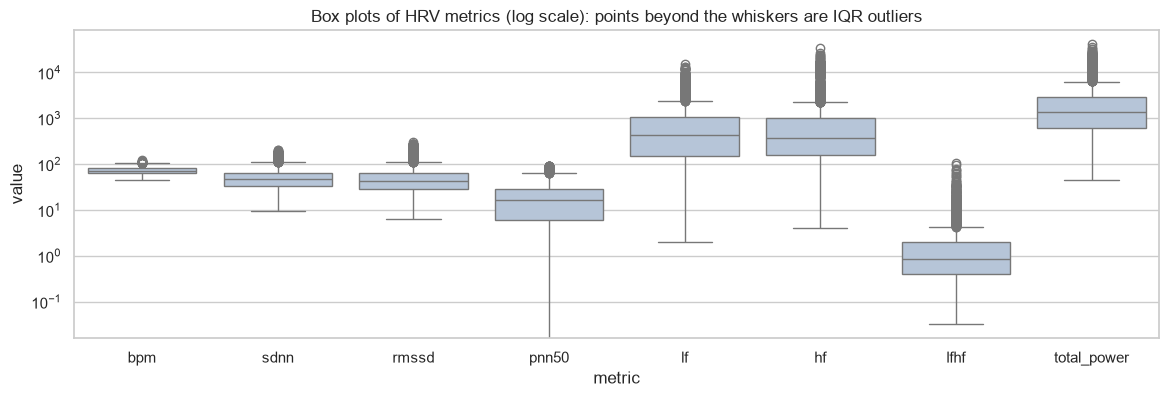

In [14]:
# Data Quality: outliers (IQR rule)
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)


outlier_cols = ["bpm", "sdnn", "rmssd", "pnn50", "lf", "hf", "lfhf", "total_power"]
iqr_flags = pd.DataFrame({c: iqr_outliers(hrv_raw[c]) for c in outlier_cols})
print("IQR (1.5x) outliers per column:")
print(iqr_flags.sum())
print(f"\nrows flagged in at least one column: {iqr_flags.any(axis=1).sum()} ({iqr_flags.any(axis=1).mean():.1%})")

# Box plots to identify outliers
fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(data=hrv_raw[outlier_cols].melt(var_name="metric"), x="metric", y="value", ax=ax, color="lightsteelblue")
ax.set(yscale="log", title="Box plots of HRV metrics (log scale): points beyond the whiskers are IQR outliers")
plt.show()

### Interpretation
* **Far too many rows are flagged to all be errors.** A quarter of all rows is flagged in at least one column.
* **Spectral powers:** for `lf`, `hf`, `lfhf` and `total_power`, most flagged points are simply the natural long tail of a log-normal distribution; on the log-scale box plot they sit on a continuous tail.
* **The real question is *why* a value is extreme.** It can be genuine physiology (a fit young person can have RMSSD > 100 ms) or a measurement error. Section 5.4 answers this with domain knowledge and the raw RR data. **Only values that are demonstrably errors will be removed (Section 8.3).**

## 5.4 Do the values make sense? (domain knowledge and validity)

In [15]:
# Physiological and logical plausibility rules
rules = {
    "bpm outside 30-220": ~hrv_raw["bpm"].between(30, 220),
    "pnn50 outside 0-100 %": ~hrv_raw["pnn50"].between(0, 100),
    "rmssd or sdnn <= 0": (hrv_raw["rmssd"] <= 0) | (hrv_raw["sdnn"] <= 0),
    "rmssd > 150 ms (unusually high at rest)": hrv_raw["rmssd"] > 150,
}
print("hrv_measurements rule violations:")
for rule, mask in rules.items():
    print(f"  {rule:<45} {mask.sum():>5}")

print("\nheart_rate readings < 30 bpm:", (raw["heart_rate"]["heart_rate"] < 30).sum(),
      "| > 220 bpm:", (raw["heart_rate"]["heart_rate"] > 220).sum())

print("\nparticipants with height outside 140-210 cm:")
print(participants_raw.loc[participants_raw["height"].notna() & ~participants_raw["height"].between(140, 210),
                           ["user_code", "gender", "age_range", "height", "weight", "country"]])

onset_raw = pd.to_datetime(participants_raw["symptoms_onset"], format="%m/%d/%Y")
implausible_onset = onset_raw.notna() & ~onset_raw.between("2019-12-01", "2020-06-30")
print(f"\nsymptoms_onset outside the study window (Dec 2019 - Jun 2020): {implausible_onset.sum()} users")
print(sorted(onset_raw[implausible_onset].dt.date.astype(str)))

hrv_measurements rule violations:
  bpm outside 30-220                                0
  pnn50 outside 0-100 %                             0
  rmssd or sdnn <= 0                                0
  rmssd > 150 ms (unusually high at rest)         118

heart_rate readings < 30 bpm: 100 | > 220 bpm: 14

participants with height outside 140-210 cm:
      user_code gender age_range  height   weight        country
49   3fff7627ca      m     35-44  248.92  114.713  United States
65   5214210ed1      f     45-54  132.08   67.903  United States
102  83161408c1      m     25-34  250.00   82.146           Iraq

symptoms_onset outside the study window (Dec 2019 - Jun 2020): 13 users
['1967-01-30', '1968-08-15', '1975-03-28', '1977-11-20', '1981-11-26', '1982-12-16', '1984-04-05', '1987-07-07', '1993-01-01', '1999-03-06', '2000-06-07', '2021-04-01', '2022-04-21']


Next I check whether the **derived metrics are accurate** by recomputing them from the raw RR intervals. I also score every recording for **artifacts**. I use the common Malik criterion: a beat is flagged when its RR interval differs from the previous one by more than 20%, which is almost impossible physiologically at rest and typical of missed or extra detected beats.

In [16]:
rr_series = hrv_raw["rr_data"].map(lambda s: np.array(s.split(","), dtype=float))

recomputed = pd.DataFrame({
    "meanrr": rr_series.map(np.mean),
    "sdnn": rr_series.map(lambda a: np.std(a, ddof=1)),
    "rmssd": rr_series.map(lambda a: np.sqrt(np.mean(np.diff(a) ** 2))),
})
for col in recomputed:
    print(f"{col:>7}: max |reported - recomputed from rr_data| = {(hrv_raw[col] - recomputed[col]).abs().max():.3f} ms")
print(f"total_power vs lf + hf + vlf : max abs diff = {(hrv_raw['total_power'] - hrv_raw[['lf', 'hf', 'vlf']].sum(axis=1)).abs().max():.3f}")
print(f"lfhf vs lf / hf              : max abs diff = {(hrv_raw['lfhf'] - hrv_raw['lf'] / hrv_raw['hf']).abs().max():.4f}")
print(f"bpm vs 60000 / meanrr        : max abs diff = {(hrv_raw['bpm'] - 60000 / hrv_raw['meanrr']).abs().max():.2f} bpm")
n_diffs = rr_series.map(len) - 1
pnn50_steps = hrv_raw["pnn50"] * n_diffs / 100
print(f"pnn50 is an exact multiple of 100/(beats-1): {np.isclose(pnn50_steps, pnn50_steps.round(), atol=0.02).mean():.1%} of recordings")


def rr_artifact_pct(rr, threshold=0.20):
    # % of beats whose RR interval changes by more than `threshold` relative to the previous beat
    return 100 * np.mean(np.abs(np.diff(rr)) / rr[:-1] > threshold)


artifact_pct = rr_series.map(rr_artifact_pct)
print("\nartifact beats per recording (%):")
print(artifact_pct.describe().round(2))
for t in [5, 10, 20]:
    flagged = artifact_pct > t
    print(f"recordings with > {t:>2}% artifact beats: {flagged.sum():>4} ({flagged.mean():.1%}) from {hrv_raw.loc[flagged, 'user_code'].nunique()} users")

 meanrr: max |reported - recomputed from rr_data| = 0.000 ms
   sdnn: max |reported - recomputed from rr_data| = 0.000 ms
  rmssd: max |reported - recomputed from rr_data| = 0.000 ms
total_power vs lf + hf + vlf : max abs diff = 0.000
lfhf vs lf / hf              : max abs diff = 0.0005
bpm vs 60000 / meanrr        : max abs diff = 3.47 bpm
pnn50 is an exact multiple of 100/(beats-1): 100.0% of recordings

artifact beats per recording (%):
count    3245.00
mean        2.80
std         8.26
min         0.00
25%         0.00
50%         0.00
75%         2.02
max        63.64
Name: rr_data, dtype: float64
recordings with >  5% artifact beats:  381 (11.7%) from 76 users
recordings with > 10% artifact beats:  170 (5.2%) from 35 users
recordings with > 20% artifact beats:  109 (3.4%) from 9 users


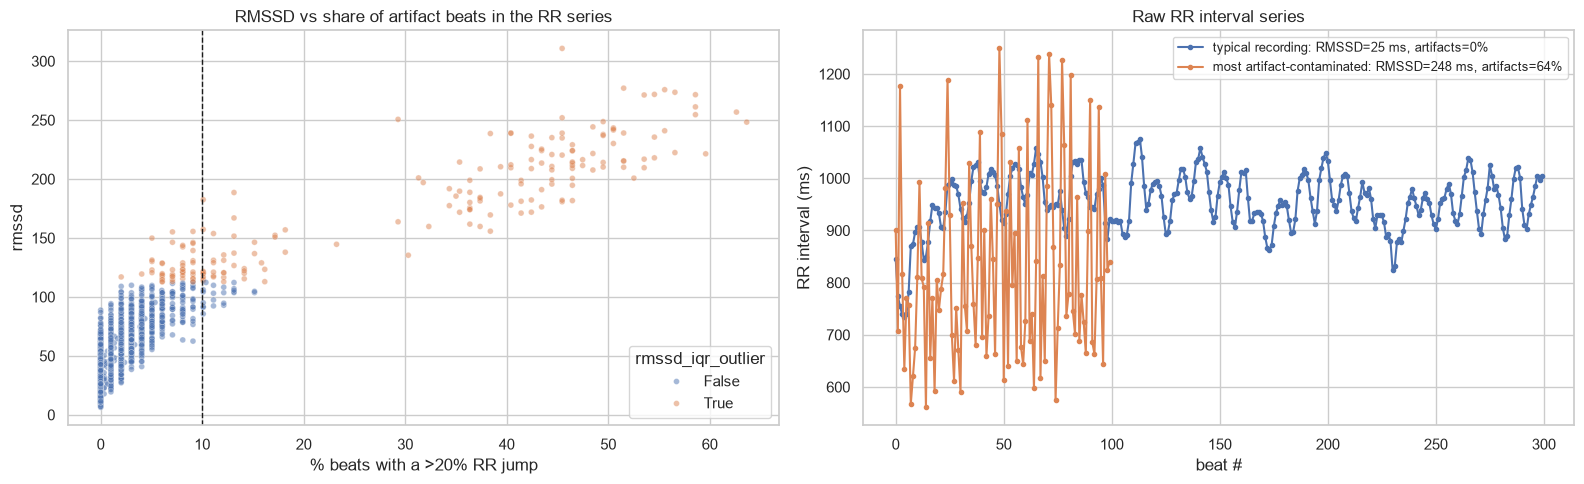

Spearman(rr_artifact_pct, rmssd) = 0.78
median RMSSD by artifact band: {'0%': 31.3, '0-5%': 56.9, '5-10%': 91.2, '10-20%': 117.9, '>20%': 211.5}
share of >10%-artifact recordings that are RMSSD IQR outliers: 0.87


,n,median_rmssd,median_artifact_pct,share_with_artifact_gt10
rmssd_iqr_outlier,,,,
False,3050,41.14,0.00,0.01
True,195,175.57,35.35,0.76


In [17]:
# Are the RMSSD outliers explained by artifacts?
quality = hrv_raw[["user_code", "rmssd", "rr_data"]].assign(rr_artifact_pct=artifact_pct, rmssd_iqr_outlier=iqr_flags["rmssd"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=quality, x="rr_artifact_pct", y="rmssd", hue="rmssd_iqr_outlier", alpha=0.5, s=18, ax=axes[0])
axes[0].axvline(10, ls="--", c="k", lw=1)
axes[0].set(title="RMSSD vs share of artifact beats in the RR series", xlabel="% beats with a >20% RR jump")

examples = quality.sort_values("rr_artifact_pct").iloc[[len(quality) // 2, -1]]
for (_, row), label in zip(examples.iterrows(), ["typical recording", "most artifact-contaminated"]):
    axes[1].plot(np.array(row["rr_data"].split(","), dtype=float), marker=".",
                 label=f"{label}: RMSSD={row['rmssd']:.0f} ms, artifacts={row['rr_artifact_pct']:.0f}%")
axes[1].set(title="Raw RR interval series", xlabel="beat #", ylabel="RR interval (ms)")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Spearman(rr_artifact_pct, rmssd) =", round(quality["rr_artifact_pct"].corr(quality["rmssd"], method="spearman"), 2))
artifact_band = pd.cut(quality["rr_artifact_pct"], bins=[-0.1, 0, 5, 10, 20, 100], labels=["0%", "0-5%", "5-10%", "10-20%", ">20%"])
print("median RMSSD by artifact band:", quality.groupby(artifact_band, observed=True)["rmssd"].median().round(1).to_dict())
print("share of >10%-artifact recordings that are RMSSD IQR outliers:",
      round(quality.loc[quality["rr_artifact_pct"] > 10, "rmssd_iqr_outlier"].mean(), 2))
quality.groupby("rmssd_iqr_outlier").agg(
    n=("rmssd", "size"),
    median_rmssd=("rmssd", "median"),
    median_artifact_pct=("rr_artifact_pct", "median"),
    share_with_artifact_gt10=("rr_artifact_pct", lambda s: (s > 10).mean()),
).round(2)

In [18]:
# Where does the implausible RMSSD of the 65-74 age group (seen in section 6) come from?
age_by_user = participants_raw.set_index("user_code")["age_range"]
older = quality[quality["user_code"].map(age_by_user) == "65-74"]
print("65-74 group:", older["user_code"].nunique(), "users,", len(older), "recordings")
older.groupby("user_code").agg(
    recordings=("rmssd", "size"),
    median_rmssd=("rmssd", "median"),
    median_artifact_pct=("rr_artifact_pct", "median"),
).sort_values("recordings", ascending=False)

65-74 group: 7 users, 109 recordings


,recordings,median_rmssd,median_artifact_pct
user_code,,,
f9edcb7056,101,213.3860,45.454545
9f680d5653,2,27.2615,1.515152
e792bd2c05,2,68.6825,3.030303
6c6e3caf6b,1,24.6160,0.000000
393bac62f4,1,21.3020,0.000000
132e23c487,1,103.5300,3.030303
ef9d2789e3,1,62.9320,2.020202


### Interpretation

#### Plausibility
* **Basic validity passes.** There are no impossible heart rates, pNN50 values outside 0–100%, or non-positive variability values in `hrv_measurements`.
* **Height entry errors:** 248.92 cm is *exactly* 98 inches and 132.08 cm is *exactly* 52 inches, which points to mistakes on the imperial input path (Section 5.2). 250.00 cm looks like a slider maximum. None of the three values can be trusted.
* **Impossible onset dates:** 13 users have `symptoms_onset` dates between 1967 and 2000, or in 2021–2022.
  * The pre-2000 dates look like **birth dates typed into the wrong field**.
  * The 2021–2022 dates are in the future relative to data collection.
  * This accuracy problem is invisible to a simple non-null check.
* **`heart_rate`:** passive readings include 100 values below 30 bpm and 14 above 220 bpm, which are wearable glitches.

#### Accuracy of derived metrics
* **The provider's computations are exact.**
  * RMSSD, SDNN and mean RR recompute from `rr_data` with essentially zero difference.
  * `total_power` = LF + HF + VLF and `lfhf` = LF / HF hold exactly.
  * `pnn50` is always an exact multiple of 100/(beats − 1).
  * `bpm` ≈ 60000 / `meanrr` (within ~3.5 bpm, from rounding).

  So the *lineage* of these columns is clear: the stored `rr_data` window → derived metrics.
* **The metrics inherit every error in the raw signal.** The app does **not** remove artifacts before computing HRV. 170 recordings (5.2%, from 35 users) have more than 10% artifact beats. Camera-PPG recordings are prone to motion, finger-pressure changes and ectopic beats, and a single spurious beat creates two huge successive differences that inflate RMSSD.

#### Outliers explained
* **Most RMSSD outliers are artifacts, not physiology.**
  * The typical RMSSD outlier has about 35% artifact beats, versus 0% for non-outliers.
  * 76% of RMSSD outliers exceed 10% artifact beats, compared with 1% of normal values.
  * The raw RR plot shows why: a few spikes (missed or extra beats) produce enormous successive differences.
* **The 65–74 anomaly comes from one user.** A single person contributes 101 of the group's 109 recordings, with a median of about 45% artifact beats. That could be an arrhythmia (e.g. atrial fibrillation or frequent ectopic beats) or a poor camera signal. Either way, RMSSD no longer measures vagal tone in those recordings.
* **Artifacts matter even below 10%:** median RMSSD rises steadily with the artifact share (31 ms at 0% → 57 ms at 0–5% → 91 ms at 5–10%).

The resulting cleaning decision is in Section 8.3.

# 6. Variable Relationships

## Questions we are asking:
* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?

I use **Spearman** rank correlation instead of the template's default Pearson correlation. The reason is that Section 4 showed skewed variables with heavy tails, and the relationships are monotonic but not necessarily linear.


Variable Relationships
----------------------
Correlation Matrix (Spearman):
              bpm  meanrr  sdnn  rmssd  pnn50   amo    lf    hf   vlf  lfhf  total_power  how_feel  how_mood  how_sleep
bpm          1.00   -1.00 -0.47  -0.39  -0.51  0.52 -0.40 -0.45 -0.37 -0.03        -0.49     -0.07     -0.03      -0.11
meanrr      -1.00    1.00  0.49   0.42   0.53 -0.54  0.42  0.48  0.39  0.02         0.51      0.08      0.03       0.11
sdnn        -0.47    0.49  1.00   0.86   0.77 -0.84  0.78  0.75  0.67  0.06         0.89      0.09      0.06       0.07
rmssd       -0.39    0.42  0.86   1.00   0.87 -0.67  0.57  0.84  0.43 -0.25         0.73      0.04      0.02       0.02
pnn50       -0.51    0.53  0.77   0.87   1.00 -0.76  0.57  0.87  0.42 -0.28         0.75      0.05      0.03       0.02
amo          0.52   -0.54 -0.84  -0.67  -0.76  1.00 -0.75 -0.69 -0.64 -0.09        -0.85     -0.09     -0.07      -0.06
lf          -0.40    0.42  0.78   0.57   0.57 -0.75  1.00  0.59  0.60  0.47       

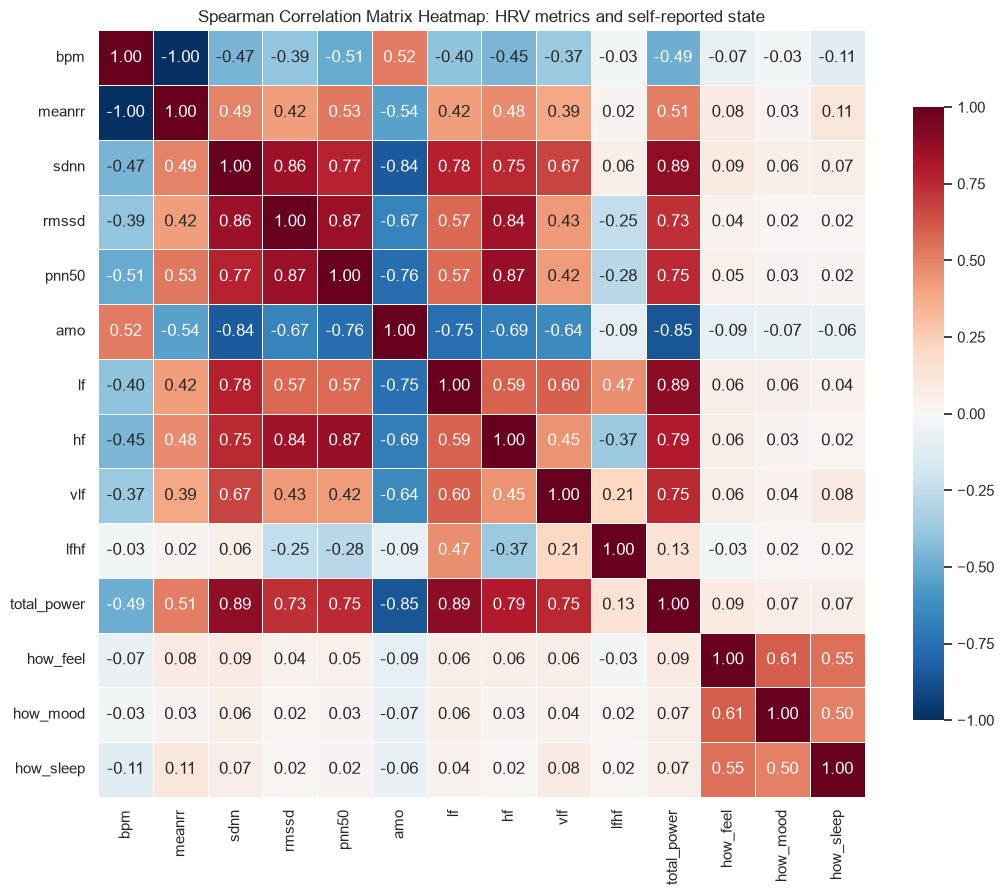

In [19]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")
print("Correlation Matrix (Spearman):")
corr_cols = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "amo", "lf", "hf", "vlf", "lfhf", "total_power",
             "how_feel", "how_mood", "how_sleep"]
correlation_matrix = hrv_raw[corr_cols].corr(method="spearman")
print(correlation_matrix.round(2))

# Visualize the Correlation Matrix
plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            linewidths=.5, cbar_kws={"shrink": 0.8})
plt.title("Spearman Correlation Matrix Heatmap: HRV metrics and self-reported state")
plt.tight_layout()
plt.show()

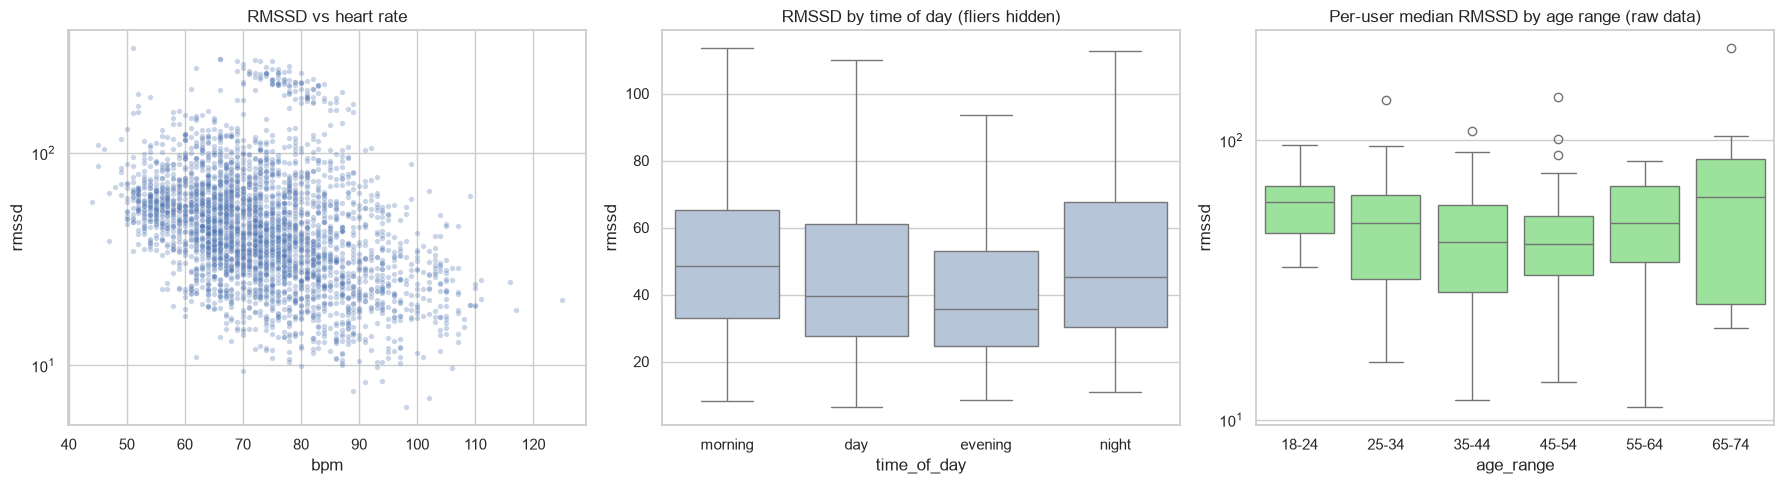

median RMSSD by time_of_day: {'day': 39.5, 'evening': 35.6, 'morning': 48.5, 'night': 45.1}
row-level median RMSSD by age_range: {'18-24': 62.4, '25-34': 42.4, '35-44': 42.1, '45-54': 40.4, '55-64': 41.1, '65-74': 210.7}
mean bpm by gender: {'f': 75.5, 'm': 69.3}


In [20]:
# Categorical vs numerical variables
hrv_with_demo = hrv_raw.merge(participants_raw[["user_code", "age_range", "gender"]], on="user_code", how="left")
user_level = hrv_with_demo.groupby(["user_code", "age_range", "gender"], as_index=False)["rmssd"].median()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=hrv_raw, x="bpm", y="rmssd", alpha=0.3, s=15, ax=axes[0])
axes[0].set(title="RMSSD vs heart rate", yscale="log")
sns.boxplot(data=hrv_raw, x="time_of_day", y="rmssd", order=order_tod, ax=axes[1], color="lightsteelblue", showfliers=False)
axes[1].set(title="RMSSD by time of day (fliers hidden)")
sns.boxplot(data=user_level, x="age_range", y="rmssd", order=age_order, ax=axes[2], color="lightgreen")
axes[2].set(title="Per-user median RMSSD by age range (raw data)", yscale="log")
plt.tight_layout()
plt.show()

print("median RMSSD by time_of_day:", hrv_raw.groupby("time_of_day")["rmssd"].median().round(1).to_dict())
print("row-level median RMSSD by age_range:", hrv_with_demo.groupby("age_range")["rmssd"].median().round(1).to_dict())
print("mean bpm by gender:", hrv_with_demo.groupby("gender")["bpm"].mean().round(1).to_dict())

## Interpretation
* **Redundant features:**
  * `bpm` and `meanrr` have ρ = −1.00 because bpm = 60000 / meanrr, so they carry the same information and a model should keep only one.
  * The vagal metrics `rmssd`, `pnn50` and `hf` form a tightly correlated cluster (ρ ≈ 0.84–0.87).
  * `sdnn` and `total_power` (overall variability) correlate at ρ = 0.89.
  * `amo` is strongly *negatively* related to variability (ρ ≈ −0.64 to −0.85): a tall modal peak means the RR intervals barely change.
* **Physiologically expected pattern:** faster heart rate goes with lower variability (ρ ≈ −0.4 to −0.5).
* **`lfhf` carries different information:** it is almost unrelated to overall variability and relates positively to LF (0.47) but negatively to HF (−0.37), as a ratio should.
* **Self-reports agree with each other but not with HRV.** `how_feel`, `how_mood` and `how_sleep` correlate at ρ ≈ 0.5–0.6, but their correlation with any HRV metric is |ρ| ≤ 0.11. Pooling everyone hides individual differences: an RMSSD of 40 ms may be a good day for one person and a bad day for another. This motivates a within-person feature (Section 9.2).
* **Categorical vs numerical:**
  * **Time of day is a confounder.** RMSSD is highest in the morning (median 48.5 ms) and lowest in the evening (35.6 ms), so comparisons should hold time of day constant.
  * **Gender:** women have a higher average heart rate than men (75.5 vs 69.3 bpm), as expected physiologically.
* **Red flag:** HRV normally *declines* with age, yet the 65–74 group has a row-level median RMSSD of about 210 ms, roughly 5× every other group. As shown in Section 5.4, this comes from one user with artifact-contaminated recordings, not from real physiology.

# 7. Data Visualization

## Questions we are asking:
* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?

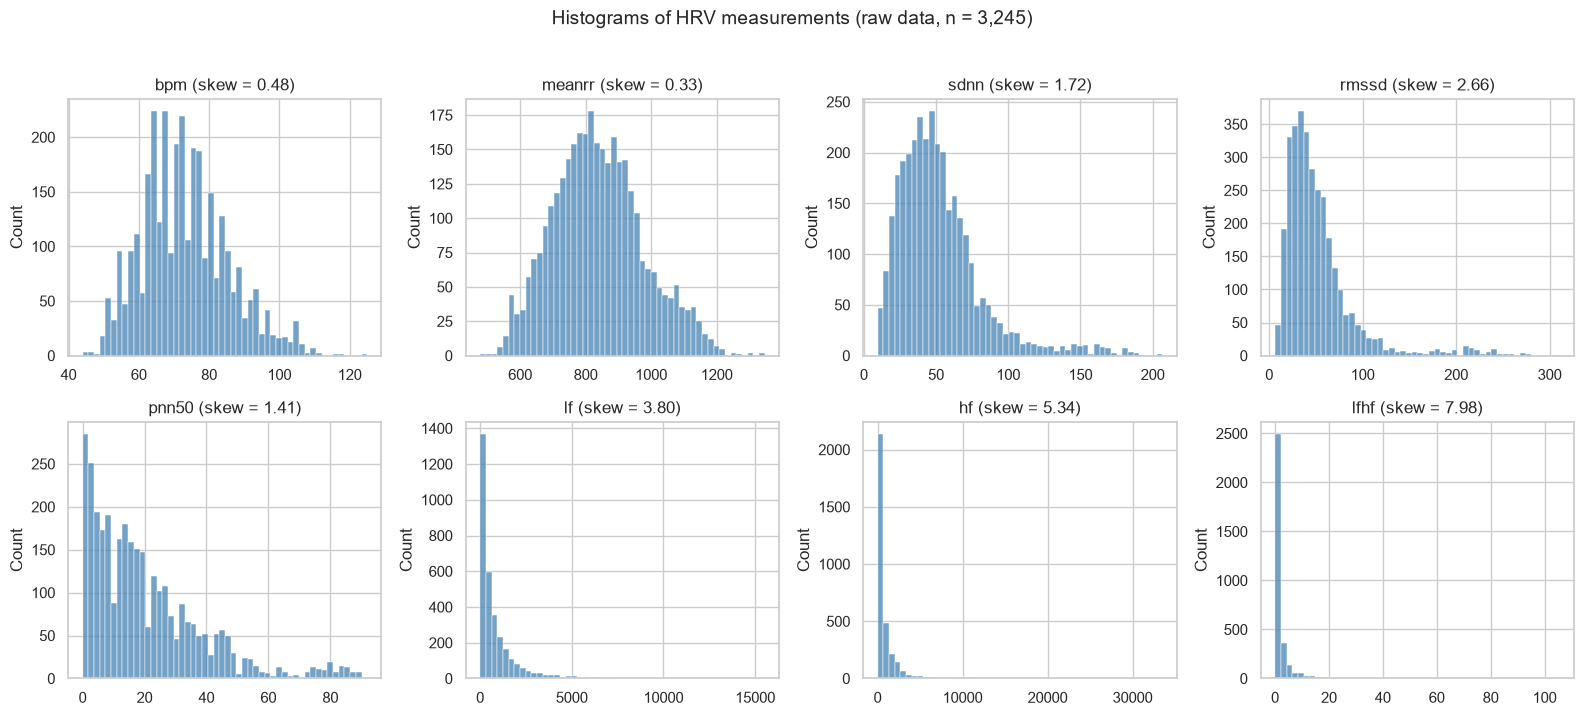

In [21]:
# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "lfhf"]):
    sns.histplot(hrv_raw[col], bins=50, ax=ax, color="steelblue")
    ax.set_title(f"{col} (skew = {hrv_raw[col].skew():.2f})")
    ax.set_xlabel("")
fig.suptitle(f"Histograms of HRV measurements (raw data, n = {len(hrv_raw):,})", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

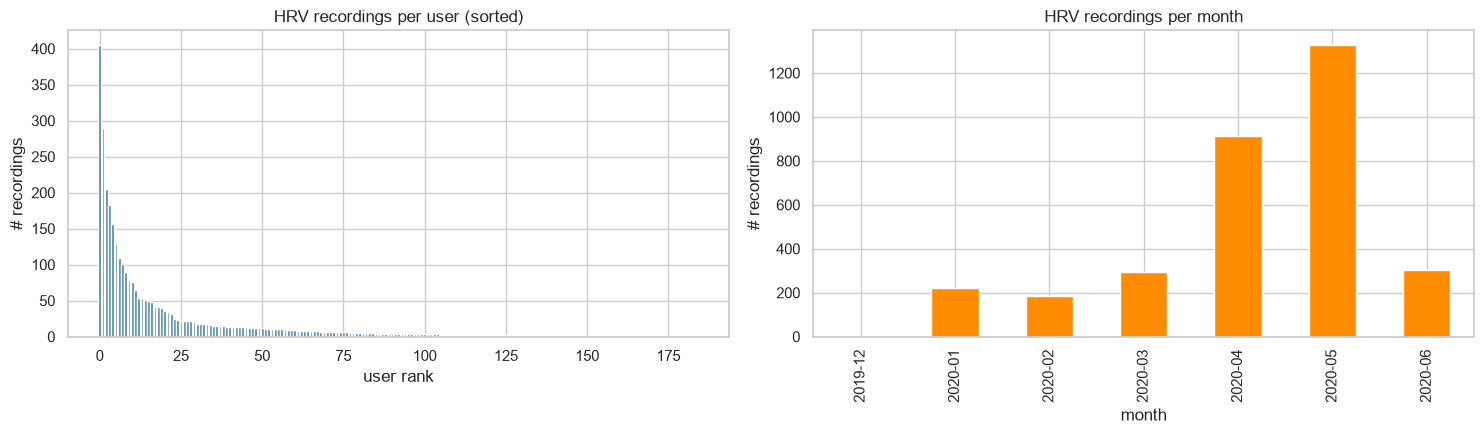

count    185.0
mean      17.5
std       45.8
min        1.0
25%        1.0
50%        4.0
75%       12.0
max      405.0
dtype: float64
top user share: 12.5% | top-5 share: 38.2% | users with a single recording: 54


In [22]:
# Who contributes the data? (sampling over users and time)
per_user = hrv_raw.groupby("user_code").size().sort_values(ascending=False)
by_month = pd.to_datetime(hrv_raw["measurement_datetime"]).dt.to_period("M").value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar(range(len(per_user)), per_user.values, color="steelblue")
axes[0].set(title="HRV recordings per user (sorted)", xlabel="user rank", ylabel="# recordings")
by_month.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set(title="HRV recordings per month", xlabel="month", ylabel="# recordings")
plt.tight_layout()
plt.show()

print(per_user.describe().round(1))
print(f"top user share: {per_user.iloc[0] / len(hrv_raw):.1%} | top-5 share: {per_user.head(5).sum() / len(hrv_raw):.1%}"
      f" | users with a single recording: {(per_user == 1).sum()}")

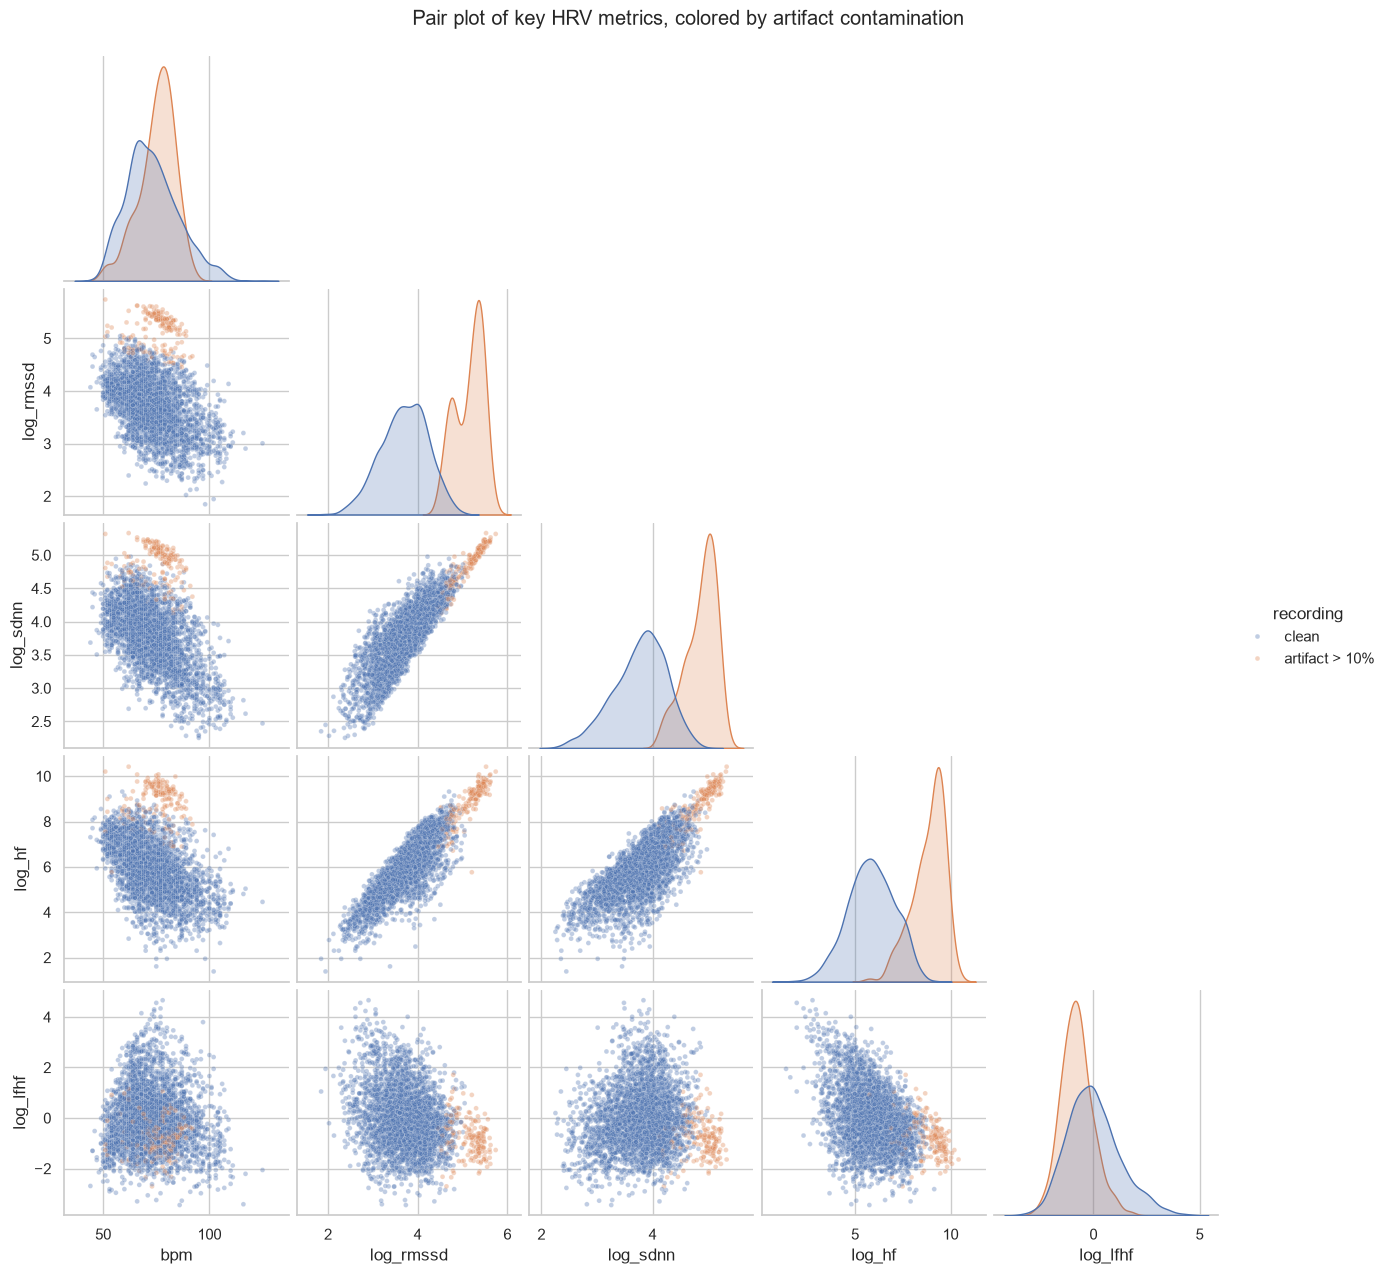

                 bpm  log_rmssd  log_sdnn  log_hf  log_lfhf
recording                                                  
artifact > 10%  76.0       5.21      4.93    9.11     -0.79
clean           72.0       3.72      3.82    5.84     -0.11


In [23]:
# Pair plot: are there subgroups / clusters? (log scale for the skewed metrics)
pair_df = pd.DataFrame({
    "bpm": hrv_raw["bpm"],
    "log_rmssd": np.log(hrv_raw["rmssd"]),
    "log_sdnn": np.log(hrv_raw["sdnn"]),
    "log_hf": np.log(hrv_raw["hf"]),
    "log_lfhf": np.log(hrv_raw["lfhf"]),
    "recording": np.where(artifact_pct > 10, "artifact > 10%", "clean"),
})
g = sns.pairplot(pair_df, hue="recording", hue_order=["clean", "artifact > 10%"], corner=True,
                 plot_kws={"alpha": 0.35, "s": 12}, diag_kws={"common_norm": False})
g.fig.suptitle("Pair plot of key HRV metrics, colored by artifact contamination", y=1.02)
plt.show()

print(pair_df.groupby("recording").median().round(2))

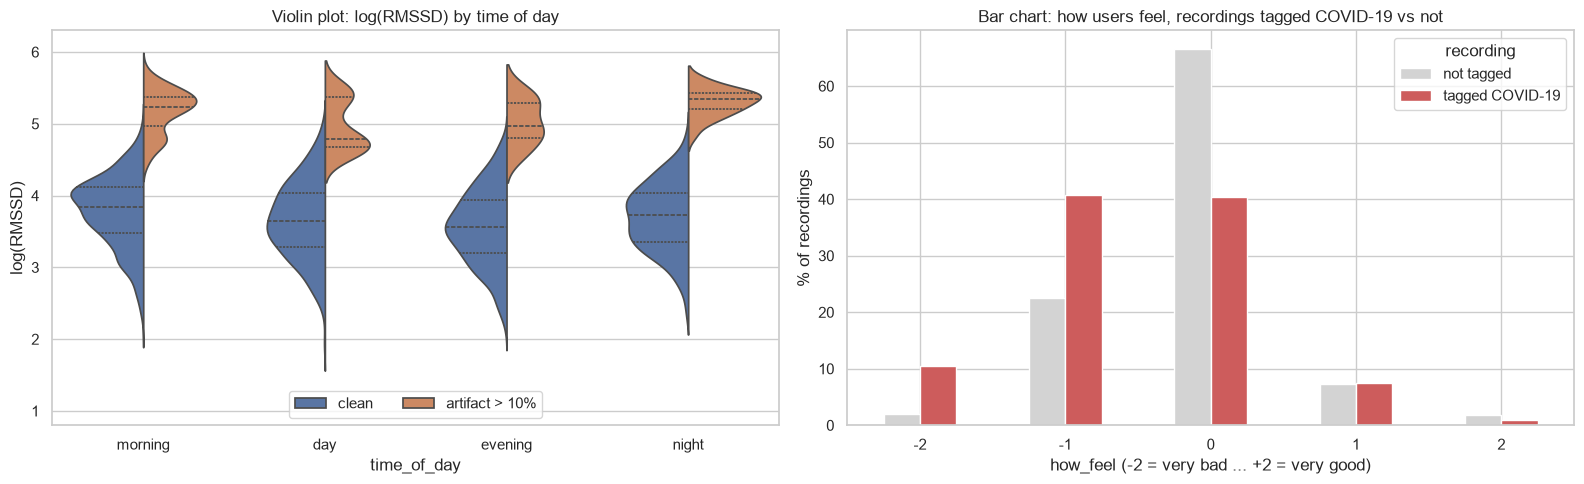

% of recordings per how_feel answer:
how_feel           -2    -1     0    1    2
recording                                  
not tagged        2.0  22.4  66.5  7.3  1.8
tagged COVID-19  10.4  40.8  40.4  7.4  1.0

median log(RMSSD) of clean recordings by time_of_day: {'day': 3.65, 'evening': 3.56, 'morning': 3.84, 'night': 3.72}


In [24]:
# Violin plot and bar chart: subgroups by time of day and by COVID-19 tag
tagged = pd.Series(np.where(hrv_raw["tags"].fillna("").str.contains("COVID-19", regex=False), "tagged COVID-19", "not tagged"),
                   index=hrv_raw.index, name="recording")
feel_share = pd.crosstab(tagged, hrv_raw["how_feel"], normalize="index") * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.violinplot(data=pair_df.assign(time_of_day=hrv_raw["time_of_day"]), x="time_of_day", y="log_rmssd", hue="recording",
               order=order_tod, hue_order=["clean", "artifact > 10%"], split=True, inner="quart", ax=axes[0])
axes[0].set(title="Violin plot: log(RMSSD) by time of day", ylabel="log(RMSSD)", ylim=(0.8, 6.3))
sns.move_legend(axes[0], "lower center", ncol=2, title=None)
feel_share.T.plot(kind="bar", ax=axes[1], color=["lightgray", "indianred"], rot=0)
axes[1].set(title="Bar chart: how users feel, recordings tagged COVID-19 vs not",
            xlabel="how_feel (-2 = very bad ... +2 = very good)", ylabel="% of recordings")
plt.tight_layout()
plt.show()

print("% of recordings per how_feel answer:")
print(feel_share.round(1))
print("\nmedian log(RMSSD) of clean recordings by time_of_day:",
      pair_df[pair_df["recording"] == "clean"].groupby(hrv_raw["time_of_day"])["log_rmssd"].median().round(2).to_dict())

## Interpretation

#### Histograms:
`bpm` and `meanrr` are roughly bell-shaped, but every variability metric has a long right tail. Two consequences follow:
1. I summarize with **medians/IQR and Spearman correlations** rather than means and Pearson correlations, because those are sensitive to the tail.
2. A **log transform** is a natural candidate (Section 9.1).

#### Recordings per User and per Month:
* **Contributions are extremely unbalanced.**
  * The median user has 4 recordings; the most active user has 405.
  * The top user alone contributes 12.5% of all rows and the top 5 contribute 38%, while 54 users have a single recording.
  * Pooled row-level statistics therefore mostly describe a handful of engaged users. **Because of this, I compare groups at the user level and engineer a within-person baseline feature (Section 9.2).**
* **Recordings are concentrated in time.** 69% were taken in April–May 2020, the first COVID-19 wave in Russia and the US. The January–March recordings of long-term users provide a pre-illness baseline.

#### Pair Plot:
* **Artifact-contaminated recordings form a visibly separate subgroup.** They sit at higher log RMSSD, SDNN and HF for the same heart rate, with a lower LF/HF ratio. This is expected, because random beat jumps add high-frequency "variability". In the metric-vs-metric panels, however, they simply extend the clean trend line. They are separable only relative to heart rate or in the raw RR series, not from the variability metrics alone.
* **Among clean recordings,** the log-scale relationships between the vagal metrics are close to linear, which confirms that the log scale is a suitable representation (Section 9.1).
* **Implication:** the artifact subgroup is not a meaningful physiological cluster but a data-quality cluster. Without cleaning, a clustering or anomaly model would mostly rediscover it.

#### Violin Plot and Bar Chart:
* **Violin plot:** clean recordings show the time-of-day pattern from Section 6 (highest in the morning). In every time slot, the artifact half of each violin sits well above the clean half, so artifacts are not specific to one time of day.
* **Bar chart:** recordings tagged "COVID-19" are shifted toward the negative answers of `how_feel`. The self-reports therefore do contain an illness signal, even though they barely correlate with raw HRV.

# 8. Data Cleaning: Missing Values, Duplicates and Outliers

## Questions we are asking:
* How should the missing values found in Section 3 be handled: drop, fill, impute, or keep?
* Should any duplicated records be removed, and by which definition of "duplicate"?
* Which outliers are errors that should be removed, and which are real extreme values that should be kept?

All cleaning works on **copies** (`participants`, `hrv`), so the raw frames stay untouched for reference. Every step that changes data is recorded in `cleaning_log` for lineage.

## 8.1 Handling missing values

| Column | Missing | Likely mechanism | Strategy | Rationale |
|---|---|---|---|---|
| `participants.city` / `country` | 12 / 6 | optional profile field skipped | `fillna("Unknown")` | Descriptive categories not used numerically. Dropping these users would throw away their HRV rows, and guessing a country would invent geography. |
| `participants.height` | 2, **+3 implausible → NaN** | skipped / entry error | leave NaN, so BMI is NaN | Only 5 users are affected. Imputing a group median would fabricate body composition for exactly the users whose data is known to be wrong. Analyses that need BMI can drop these rows explicitly. |
| `participants.symptoms_onset` | 38, **+13 implausible → NaT** | not reported / wrong field | keep NaT and put these users in an explicit `"unknown"` illness phase | The timeline cannot be inferred for these users, but their recordings are still valid for analyses that do not need it. |
| `hrv.how_sleep` | 1,779 (54.8%) | **structural**: only asked after morning measurements | keep NaN and add the indicator `how_sleep_reported` | The value is "not applicable". Mean-filling or forward-filling would invent sleep ratings for evening recordings. |
| `hrv.tags` | 1,044 (32.2%) | user did not tag | `fillna("")` | An absent tag means "no context reported". An empty string keeps that meaning and lets string operations work. |
| All HRV metrics | 0 | none | no action | Complete. |

I chose to **retain rows rather than drop them**: the dataset has only 185 users, and none of these gaps affect the HRV metrics themselves.

In [25]:
cleaning_log = []
participants = participants_raw.copy()

# Implausible values are accuracy errors, not real observations -> convert them to missing first
bad_height = participants["height"].notna() & ~participants["height"].between(140, 210)
participants.loc[bad_height, "height"] = np.nan

participants["symptoms_onset"] = pd.to_datetime(participants["symptoms_onset"], format="%m/%d/%Y")
bad_onset = participants["symptoms_onset"].notna() & ~participants["symptoms_onset"].between("2019-12-01", "2020-06-30")
participants.loc[bad_onset, "symptoms_onset"] = pd.NaT

participants[["city", "country"]] = participants[["city", "country"]].fillna("Unknown")

cleaning_log.append(("participants", "implausible height -> NaN", int(bad_height.sum())))
cleaning_log.append(("participants", "implausible symptoms_onset -> NaT", int(bad_onset.sum())))
cleaning_log.append(("participants", "city/country missing -> 'Unknown'", int(participants_raw[["city", "country"]].isna().any(axis=1).sum())))
missing_report(participants)

,n_missing,pct_missing
symptoms_onset,51,27.6
height,5,2.7


In [26]:
hrv = hrv_raw.copy()
hrv["how_sleep_reported"] = hrv["how_sleep"].notna()
hrv["tags"] = hrv["tags"].fillna("")
cleaning_log.append(("hrv", "tags missing -> ''", int(hrv_raw["tags"].isna().sum())))

print("share of recordings with a sleep rating, by time_of_day:")
print(pd.crosstab(hrv["time_of_day"], hrv["how_sleep_reported"], normalize="index").round(3))
missing_report(hrv)

share of recordings with a sleep rating, by time_of_day:
how_sleep_reported  False  True 
time_of_day                     
day                 0.969  0.031
evening             1.000  0.000
morning             0.018  0.982
night               0.996  0.004


,n_missing,pct_missing
how_sleep,1779,54.8


### Interpretation
* **What remains missing is deliberate:** `height` (5 users) and `symptoms_onset` (51 users, now 27.6% after the 13 impossible dates were converted to missing) in `participants`, and `how_sleep` in `hrv`.
* **The indicator confirms the mechanism:** 98% of morning recordings have a sleep rating versus 0–3% of all other time slots.

## 8.2 Removing duplicates
I deduplicate `hrv` on **(`user_code`, `rr_data`)** rather than on full rows. A re-uploaded recording would get a new `rr_code` and timestamp, so a full-row check could miss it, while two *independent* 100-beat RR sequences being identical is practically impossible. `keep="first"` retains the earliest copy.

In [27]:
before = len(hrv)
hrv = hrv.drop_duplicates(subset=["user_code", "rr_data"], keep="first")
participants = participants.drop_duplicates(subset="user_code", keep="first")

assert hrv["rr_code"].is_unique, "rr_code must be a primary key"
assert participants["user_code"].is_unique, "user_code must be a primary key"
cleaning_log.append(("hrv", "drop duplicate (user_code, rr_data)", before - len(hrv)))
print(f"hrv rows removed as duplicates: {before - len(hrv)}")

hrv rows removed as duplicates: 0


### Interpretation
As expected from Section 5.1, **zero duplicates were removed**. The step is kept as a guard for refreshed data, and the assertions document the primary-key constraints that the rest of the notebook relies on.

## 8.3 Handling outliers

**Decisions and rationale** (based on the evidence in Sections 5.3–5.4):
1. **Remove recordings with `rr_artifact_pct` > 10%** (170 rows, 5.2%).
   * HRV standards require artifact-free or edited recordings. Once more than 10 of 100 beats are corrupted, the series cannot be repaired without guessing. 87% of these recordings are also RMSSD outliers.
   * I chose 10% as a compromise: 5% would discard 381 recordings (11.7%), while 20% would keep clearly contaminated series.
   * **Limitation:** median RMSSD already rises with artifact share *below* 10%, so milder contamination remains in the data. I therefore keep `rr_artifact_pct` as a feature, so later analyses can apply a stricter filter or adjust for it. Beat-level artifact correction (interpolating flagged beats) would be the better long-term fix.
2. **Keep the remaining statistical outliers.** After artifact removal, the extreme values are physiologically plausible (max RMSSD ≈ 155 ms). Deleting them would bias the data toward the "average" person and could erase real illness-related changes.
3. **Handle the remaining skew with a log transform (Section 9.1) instead of winsorizing or clipping.** Log keeps the ordering and the *relative* differences between days, which matter for within-person change. Clipping would flatten exactly the unusual days that might reflect illness.
4. **Implausible heights** were already set to missing in Section 8.1.

In [28]:
hrv["rr_artifact_pct"] = artifact_pct          # new signal-quality feature (computed in 5.4)
before = len(hrv)
hrv = hrv[hrv["rr_artifact_pct"] <= 10].copy()
cleaning_log.append(("hrv", "remove artifact-contaminated recordings (>10% artifact beats)", before - len(hrv)))

print(f"removed {before - len(hrv)} recordings -> {len(hrv)} remain from {hrv['user_code'].nunique()} users")
print("RMSSD skew before -> after:", round(hrv_raw["rmssd"].skew(), 2), "->", round(hrv["rmssd"].skew(), 2))
print("remaining IQR outliers per column:")
print(pd.DataFrame({c: iqr_outliers(hrv[c]) for c in outlier_cols}).sum())
print("65-74 recordings left:", (hrv["user_code"].map(age_by_user) == "65-74").sum())
user_median = hrv.assign(age_range=hrv["user_code"].map(age_by_user)).groupby(["age_range", "user_code"])["rmssd"].median()
print("user-level median RMSSD by age_range after cleaning:", user_median.groupby("age_range").median().round(1).to_dict())
hrv[["bpm", "rmssd", "sdnn", "pnn50"]].describe().round(1)

removed 170 recordings -> 3075 remain from 184 users
RMSSD skew before -> after: 2.66 -> 1.06
remaining IQR outliers per column:
bpm             22
sdnn            50
rmssd           78
pnn50           32
lf             221
hf             292
lfhf           358
total_power    177
dtype: int64
65-74 recordings left: 8
user-level median RMSSD by age_range after cleaning: {'18-24': 60.1, '25-34': 50.6, '35-44': 43.3, '45-54': 41.2, '55-64': 50.5, '65-74': 45.1}


,bpm,rmssd,sdnn,pnn50
count,3075.0,3075.0,3075.0,3075.0
mean,73.1,45.8,48.0,18.1
std,12.4,23.4,21.4,14.7
min,44.0,6.3,9.5,0.0
25%,64.0,28.4,32.0,6.1
50%,72.0,41.4,45.5,15.2
75%,81.0,58.4,61.1,27.3
max,125.0,155.5,145.0,76.8


### Interpretation
* **Result:** 3,075 recordings from 184 users remain. One user lost all of their recordings.
* **Effect on RMSSD:** skewness drops from 2.66 to 1.06, the maximum falls from 310.8 to 155.5 ms, and the IQR flags only 78 RMSSD values instead of 195.
* **The 65–74 group** now has only 8 recordings, and its user-level median RMSSD is in line with the other age groups.
* **LF, HF and LF/HF** still have many IQR "outliers" after cleaning. They are the log-normal tail, which the transformation below handles.

# 9. Feature Engineering

## Questions we are asking:
* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?

## 9.1 Transforming and scaling variables

| Transformation | Columns | Rationale |
|---|---|---|
| String → `datetime64` | `measurement_datetime` (`symptoms_onset` was parsed in Section 8.1) | Enables date arithmetic (days since onset) and time-based grouping. |
| Ordered categoricals | `time_of_day`, `age_range` | They have a natural order, so plots and sorting come out right and comparisons such as "older than" are valid. |
| Code → label | `gender` (`f`/`m` → `female`/`male`) | Readability in tables and plots. |
| **Unit standardization** s → ms | `mode` → `mode_ms`, `mxdmn` → `mxdmn_ms` | Puts every RR-interval metric in one unit and prevents 1000× mistakes when comparing to `meanrr`. |
| **Natural log** | `rmssd`, `sdnn`, `lf`, `hf`, `vlf`, `total_power`, `lfhf` | These positive, right-skewed metrics are approximately log-normal (Section 4), and ln(RMSSD) is the standard HRV index in research and in apps. Changes in HRV are multiplicative, and log also reduces the leverage of the remaining extreme values. I use `np.log` rather than `log1p` because every value is > 0, and `log1p` would distort small ratios such as LF/HF = 0.03. |
| *No* global scaling | none | There is no model yet, and global z-scoring would erase the interpretable ms units. A **per-person** standardization is more meaningful here and is created as a feature in Section 9.2. |

In [29]:
hrv["measurement_datetime"] = pd.to_datetime(hrv["measurement_datetime"])
hrv["time_of_day"] = hrv["time_of_day"].astype(pd.CategoricalDtype(order_tod, ordered=True))
participants["age_range"] = participants["age_range"].astype(pd.CategoricalDtype(age_order, ordered=True))
participants["gender"] = participants["gender"].map({"f": "female", "m": "male"})

hrv["mode_ms"] = hrv["mode"] * 1000
hrv["mxdmn_ms"] = hrv["mxdmn"] * 1000
hrv = hrv.drop(columns=["mode", "mxdmn"])

log_cols = ["rmssd", "sdnn", "lf", "hf", "vlf", "total_power", "lfhf"]
assert (hrv[log_cols] > 0).all().all(), "log transform requires strictly positive values"
for col in log_cols:
    hrv[f"ln_{col}"] = np.log(hrv[col])

ln_cols = [f"ln_{c}" for c in log_cols]
pd.DataFrame({"skew_before": hrv[log_cols].skew().values, "skew_after_ln": hrv[ln_cols].skew().values,
              "kurtosis_before": hrv[log_cols].kurt().values, "kurtosis_after_ln": hrv[ln_cols].kurt().values},
             index=log_cols).round(2)

,skew_before,skew_after_ln,kurtosis_before,kurtosis_after_ln
rmssd,1.06,-0.23,1.32,-0.28
sdnn,0.74,-0.42,0.56,-0.13
lf,4.32,-0.37,30.14,-0.11
hf,3.24,-0.15,17.86,-0.27
vlf,6.60,-0.36,88.69,0.31
total_power,2.67,-0.30,10.64,-0.27
lfhf,7.79,0.49,88.88,0.27


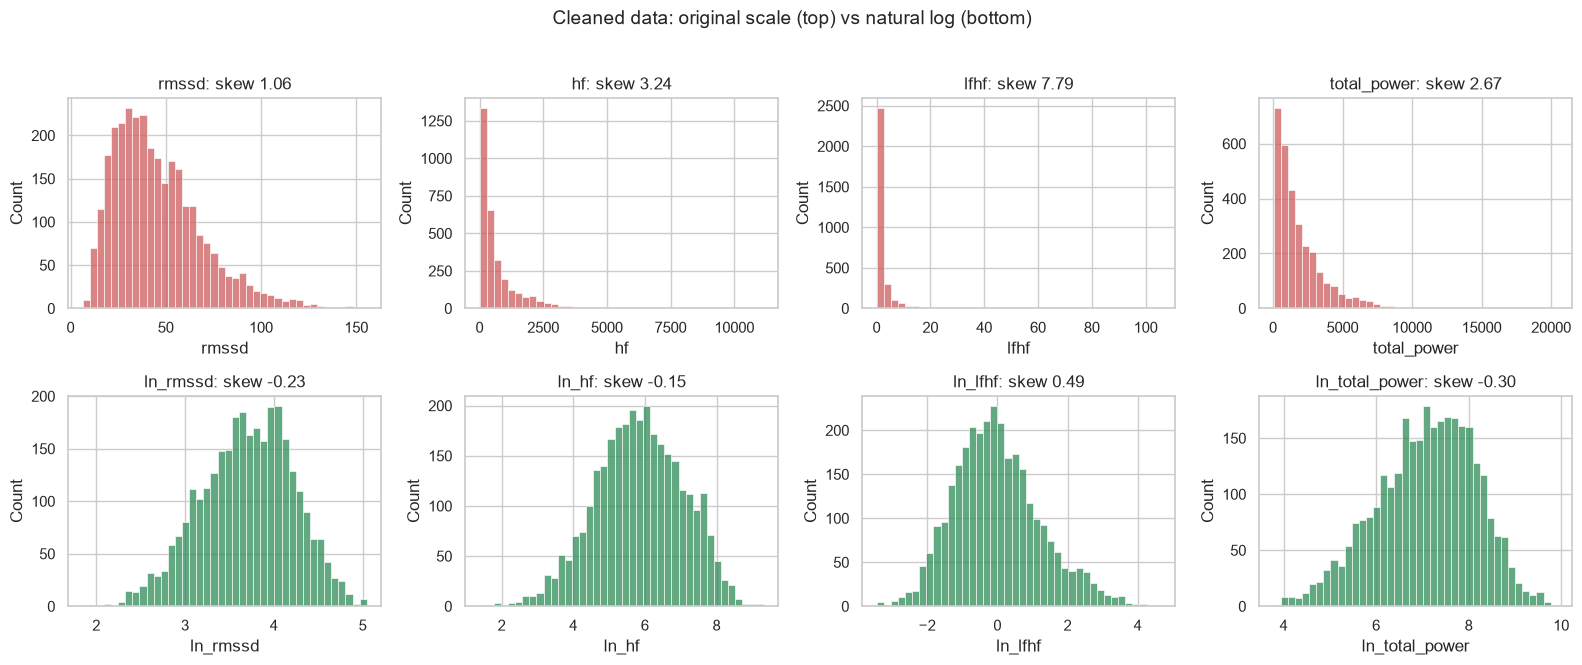

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
for i, col in enumerate(["rmssd", "hf", "lfhf", "total_power"]):
    sns.histplot(hrv[col], bins=40, ax=axes[0, i], color="indianred")
    axes[0, i].set_title(f"{col}: skew {hrv[col].skew():.2f}")
    sns.histplot(hrv[f"ln_{col}"], bins=40, ax=axes[1, i], color="seagreen")
    axes[1, i].set_title(f"ln_{col}: skew {hrv[f'ln_{col}'].skew():.2f}")
fig.suptitle("Cleaned data: original scale (top) vs natural log (bottom)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation
* **Symmetric distributions after the log:** the log transform turns the skewed distributions into roughly symmetric ones with kurtosis close to 0. For example, RMSSD skewness drops from about 1.1 to about −0.2 after cleaning.
* **The remaining "outliers" were just the tail:** those in LF, HF and LF/HF are simply the tail of a log-normal distribution, which confirms that transforming them was a better choice than removing them.

## 9.2 New features
Each new feature targets a specific problem uncovered during exploration. Several of them **combine** or **decompose** existing variables, as the template's third question suggests.

| New feature | Type | Definition | Why I created it |
|---|---|---|---|
| `rr_artifact_pct` | decomposed from `rr_data` | % of beats whose RR interval jumps > 20% (Section 5.4) | A **signal-quality score**. It drove the cleaning decision and can later be used as a filter or sample weight. |
| `ln_rmssd` (and other `ln_*`) | transformed | natural log of the metric (Section 9.1) | Normalizes the distribution; this is the standard HRV index. |
| `ln_rmssd_personal_z` | combined (recording + user history) | (`ln_rmssd` − the user's median `ln_rmssd`) / the user's SD, only for users with ≥ 5 clean recordings | HRV is highly individual and pooled correlations with well-being were ≈ 0 (Section 6). COVID-19 HRV research looks for **deviations from one's own baseline**. The median is used as the baseline because it is robust to a few sick days, and the ≥ 5 threshold avoids unstable baselines. |
| `days_since_onset` | combined (two tables) | recording date − `symptoms_onset` (days) | Places every recording on the illness timeline. |
| `illness_phase` | binned | `pre_onset` (< 0), `acute_0_13d` (0–13), `post_14d_plus` (≥ 14), `unknown` | 14 days roughly matches the acute COVID-19 / isolation period used in 2020. Coarse phases are more robust than exact days to users misremembering their onset date. |
| `bmi` | combined | weight (kg) / height (m)² | Combines two raw columns into a clinically meaningful measure associated with both HRV and COVID-19 severity. |
| `tag_covid` | decomposed from `tags` | `tags` contains "COVID-19" | The user explicitly marked the recording as illness-related (Section 7 showed these recordings have worse `how_feel`). |
| `how_sleep_reported` | indicator | `how_sleep` not missing (Section 8.1) | Preserves the structural-missingness information. |

In [31]:
df = hrv.merge(participants, on="user_code", how="left", validate="many_to_one")   # integrity check: one participant per recording

between_var = df.groupby("user_code")["ln_rmssd"].mean().var()
within_var = df.groupby("user_code")["ln_rmssd"].var().mean()
print(f"ln_rmssd variance between users (of user means): {between_var:.3f}")
print(f"ln_rmssd average variance within a user        : {within_var:.3f}")

ln_rmssd variance between users (of user means): 0.218
ln_rmssd average variance within a user        : 0.182


In [32]:
# Feature Engineering
print("\nFeature Engineering")
print("-------------------")

# 1) Deviation from the personal baseline
MIN_BASELINE_RECORDINGS = 5
by_user = df.groupby("user_code")["ln_rmssd"]
df["n_user_recordings"] = by_user.transform("size")
df["ln_rmssd_personal_z"] = (df["ln_rmssd"] - by_user.transform("median")) / by_user.transform("std")
df.loc[df["n_user_recordings"] < MIN_BASELINE_RECORDINGS, "ln_rmssd_personal_z"] = np.nan

# 2) Illness timeline
df["days_since_onset"] = (df["measurement_datetime"].dt.normalize() - df["symptoms_onset"]).dt.days
df["illness_phase"] = (
    pd.cut(df["days_since_onset"], bins=[-np.inf, -1, 13, np.inf], labels=["pre_onset", "acute_0_13d", "post_14d_plus"])
    .cat.add_categories("unknown")
    .fillna("unknown")
)

# 3) Body mass index
df["bmi"] = (df["weight"] / (df["height"] / 100) ** 2).round(1)

# 4) Self-reported COVID-19 context
df["tag_covid"] = df["tags"].str.contains("COVID-19", regex=False)

new_features = ["rr_artifact_pct", "ln_rmssd", "ln_rmssd_personal_z", "days_since_onset", "illness_phase", "bmi",
                "tag_covid", "how_sleep_reported"]
print(f"New Features: {new_features}")
print("\nillness_phase counts:\n", df["illness_phase"].value_counts())
print("\nrecordings with a personal-baseline z-score:", df["ln_rmssd_personal_z"].notna().sum(),
      "from", df.loc[df["ln_rmssd_personal_z"].notna(), "user_code"].nunique(), "users")
print("tag_covid recordings:", df["tag_covid"].sum(), "| users without BMI:", df.drop_duplicates("user_code")["bmi"].isna().sum())
df[["rr_artifact_pct", "ln_rmssd", "ln_rmssd_personal_z", "days_since_onset", "bmi"]].describe().round(2)


Feature Engineering
-------------------
New Features: ['rr_artifact_pct', 'ln_rmssd', 'ln_rmssd_personal_z', 'days_since_onset', 'illness_phase', 'bmi', 'tag_covid', 'how_sleep_reported']

illness_phase counts:
 illness_phase
post_14d_plus    1472
pre_onset         706
unknown           546
acute_0_13d       351
Name: count, dtype: int64

recordings with a personal-baseline z-score: 2902 from 83 users
tag_covid recordings: 641 | users without BMI: 5


,rr_artifact_pct,ln_rmssd,ln_rmssd_personal_z,days_since_onset,bmi
count,3075.00,3075.00,2902.00,2529.00,3061.00
mean,1.13,3.70,0.01,7.49,26.92
std,1.88,0.52,1.00,46.48,5.86
min,0.00,1.85,-5.48,-127.00,16.30
25%,0.00,3.35,-0.61,-12.00,22.20
50%,0.00,3.72,0.00,19.00,26.80
75%,2.02,4.07,0.63,38.00,30.40
max,9.09,5.05,3.33,97.00,53.30


               recordings  users  mean_bpm  mean_ln_rmssd  mean_personal_z  mean_how_feel
illness_phase                                                                            
pre_onset             706     19    73.814          3.713            0.007         -0.085
acute_0_13d           351     72    74.558          3.673           -0.114         -0.387
post_14d_plus        1472     92    72.659          3.712            0.023         -0.437


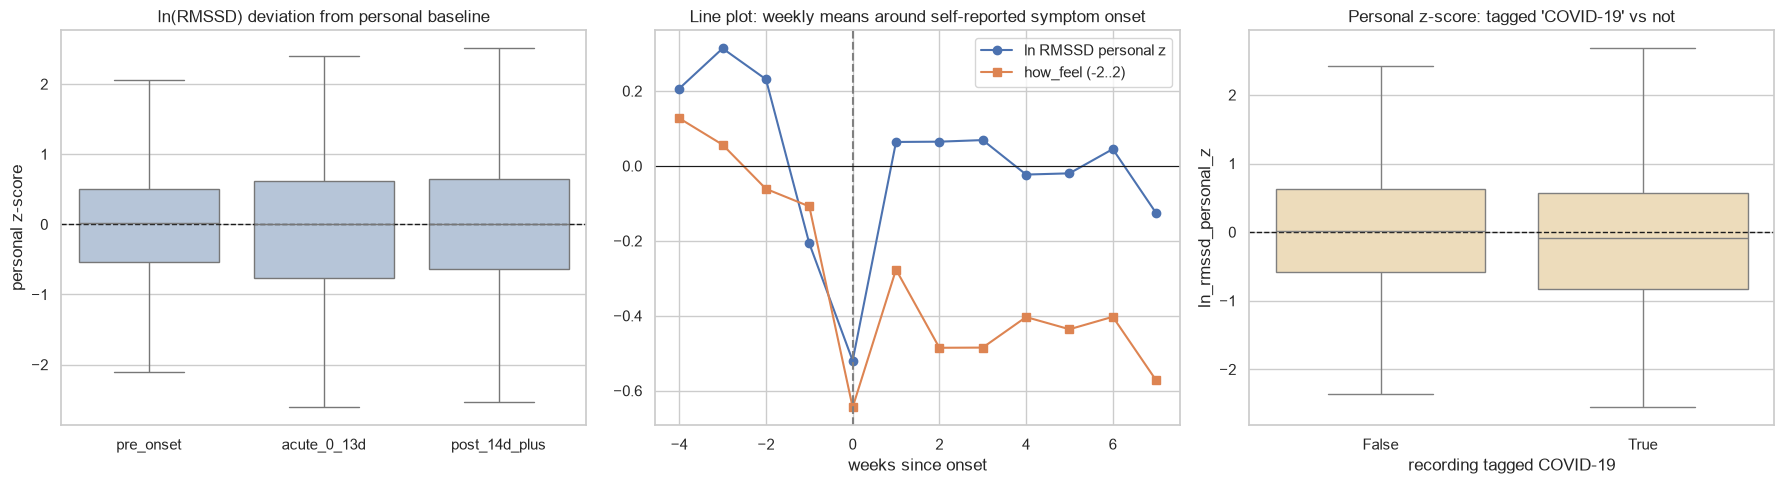

weekly means around onset (recordings with a personal baseline):
      recordings  users  ln_rmssd_personal_z  how_feel
week                                                  
-4            55      7                 0.21      0.13
-3            53      9                 0.31      0.06
-2            49      6                 0.23     -0.06
-1            37      8                -0.21     -0.11
 0            90     18                -0.52     -0.64
 1           206     34                 0.06     -0.28
 2           241     31                 0.06     -0.49
 3           233     28                 0.07     -0.48
 4           233     36                -0.02     -0.40
 5           172     31                -0.02     -0.44
 6           144     26                 0.04     -0.40
 7           152     23                -0.13     -0.57
onset week: 18 users, 61% of them below their personal baseline
mean how_feel by tag_covid: {False: -0.16, True: -0.56}
mean personal z by tag_covid: {False: 0.038, 

In [33]:
# Visualize new features
phase_order = ["pre_onset", "acute_0_13d", "post_14d_plus"]
timeline = df[df["illness_phase"].isin(phase_order)]
print(timeline.groupby("illness_phase", observed=True).agg(
    recordings=("rr_code", "size"), users=("user_code", "nunique"),
    mean_bpm=("bpm", "mean"), mean_ln_rmssd=("ln_rmssd", "mean"),
    mean_personal_z=("ln_rmssd_personal_z", "mean"), mean_how_feel=("how_feel", "mean")).round(3))

weekly = (timeline[timeline["days_since_onset"].between(-28, 55) & timeline["ln_rmssd_personal_z"].notna()]
          .assign(week=lambda d: (d["days_since_onset"] // 7).astype(int))
          .groupby("week")
          .agg(recordings=("rr_code", "size"), users=("user_code", "nunique"),
               ln_rmssd_personal_z=("ln_rmssd_personal_z", "mean"), how_feel=("how_feel", "mean")))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=timeline, x="illness_phase", y="ln_rmssd_personal_z", order=phase_order, ax=axes[0],
            color="lightsteelblue", showfliers=False)
axes[0].axhline(0, ls="--", c="k", lw=1)
axes[0].set(title="ln(RMSSD) deviation from personal baseline", ylabel="personal z-score", xlabel="")
axes[1].plot(weekly.index, weekly["ln_rmssd_personal_z"], marker="o", label="ln RMSSD personal z")
axes[1].plot(weekly.index, weekly["how_feel"], marker="s", label="how_feel (-2..2)")
axes[1].axvline(0, ls="--", c="grey")
axes[1].axhline(0, c="k", lw=0.8)
axes[1].set(title="Line plot: weekly means around self-reported symptom onset", xlabel="weeks since onset")
axes[1].legend()
sns.boxplot(data=df, x="tag_covid", y="ln_rmssd_personal_z", ax=axes[2], color="wheat", showfliers=False)
axes[2].axhline(0, ls="--", c="k", lw=1)
axes[2].set(title="Personal z-score: tagged 'COVID-19' vs not", xlabel="recording tagged COVID-19")
plt.tight_layout()
plt.show()

print("weekly means around onset (recordings with a personal baseline):")
print(weekly.round(2))
week0 = timeline[timeline["days_since_onset"].between(0, 6)].groupby("user_code")["ln_rmssd_personal_z"].mean().dropna()
print(f"onset week: {len(week0)} users, {(week0 < 0).mean():.0%} of them below their personal baseline")
print("mean how_feel by tag_covid:", df.groupby("tag_covid")["how_feel"].mean().round(2).to_dict())
print("mean personal z by tag_covid:", df.groupby("tag_covid")["ln_rmssd_personal_z"].mean().round(3).to_dict())
print("Spearman(personal z, how_feel):", round(df["ln_rmssd_personal_z"].corr(df["how_feel"], method="spearman"), 3),
      "| Spearman(raw rmssd, how_feel):", round(df["rmssd"].corr(df["how_feel"], method="spearman"), 3))

## Interpretation

#### New Feature: `rr_artifact_pct` (signal quality)
Decomposing the raw RR series into a single quality score was the key to this analysis. It explained the RMSSD outliers and the false age effect, and it gave the outlier handling an objective, reproducible rule (Section 8.3).

#### New Feature: `ln_rmssd_personal_z` (deviation from the personal baseline)
* **Why a personal baseline:** the variance of users' average `ln_rmssd` (between-person variation) is *larger* than the typical day-to-day variance within a single user. A raw RMSSD value mostly says *who* the person is, not *how they are doing today*, and the personal z-score removes that between-person component.
* **Trade-off, coverage:** only 83 users with ≥ 5 clean recordings get a z-score.
* **Week by week around symptom onset** (middle plot):
  * In weeks −4 to −2, recordings sit slightly *above* each person's baseline (z ≈ +0.2 to +0.3).
  * The z-score starts falling in week −1 (≈ −0.2) and reaches its lowest point in the **onset week** (week 0: z ≈ −0.5), which is also when `how_feel` is lowest.
  * From week 1 onward, HRV is back at roughly baseline (z ≈ 0), while `how_feel` stays clearly negative.

  This is consistent with the hypothesis behind the dataset: HRV drops around, and possibly just before, symptom onset. It is only visible *because* of the new feature; raw RMSSD correlates with `how_feel` at ρ ≈ 0.02.

#### New Features: `days_since_onset` and `illness_phase`
* **Acute phase (first 2 weeks after onset):**
  * The phase mean is only slightly below baseline (z ≈ −0.11), because the dip lasts about one week and week 1 has already recovered. That shows how the choice of window length affects what we see.
  * Mean heart rate is slightly higher than before onset (74.6 vs 73.8 bpm).
  * Self-rated well-being drops sharply (`how_feel` −0.09 → −0.39).

  This direction matches the expected effect of infection (reduced vagal tone, higher HR).
* **Post phase (≥ 14 days):** HRV returns to baseline, but `how_feel` stays low. This is consistent with lingering symptoms, or with the fact that people who keep measuring for weeks may be the ones still feeling unwell (engagement bias again).

#### New Features: `bmi`, `tag_covid`, `how_sleep_reported`
* **`bmi`:** combines height and weight. It is missing for the 5 users whose height was missing or invalid.
* **`tag_covid`:** recordings tagged "COVID-19" have clearly lower `how_feel` (−0.56 vs −0.16) and a slightly negative personal z-score.
* **`how_sleep_reported`:** keeps the information that the sleep question was asked, which matters for any model that uses `how_sleep`.

**Caveats** (exploratory, not causal):
* Sample sizes are small. Each pre-onset week has only 6–9 users with a baseline, and in the onset week (18 users) only about 60% are below their own baseline, so the dip is not universal.
* The pre-onset phase as a whole comes from only 19 users, so a few heavy users dominate it.
* Onset dates are self-reported, and the overall correlation between the personal z-score and `how_feel` remains weak.

# 10. Data Quality Assessment

## Data profiling
I profiled the data at three levels:
1. **Table level** (Section 2): size, user coverage, overall missingness, duplicates, date range.
2. **Schema level** (Section 3): dtypes, keys, cardinality, format of every column.
3. **Column level** (Sections 4–7): central tendency, dispersion and distribution of every HRV metric, most frequent values, categorical frequencies, and correlations.

Profiling is what showed the heavy skew, the unit mismatches, the discretized `mode`, the implausible age pattern, and that 7 of the 9 tables were too sparse to be worth a deep dive.

## Data completeness
* **Values:**
  * The core HRV metrics are 100% complete, and `gender` / `age_range` are complete.
  * `city` is 93.5% complete and `height` 98.9% (97.3% after invalid values were removed).
  * `symptoms_onset` is only 79.5% complete (72.4% after the 13 impossible dates were removed), which limits every timeline analysis.
* **Coverage, the bigger issue:**
  * There are only 185 users, and the median user has just 4 recordings.
  * 54 users have a single recording, and only 83 users have enough clean recordings (≥ 5) for a personal baseline.
  * The secondary tables cover 5–60% of users, so a complete multimodal picture of each person is impossible.
* **Structural missingness** (`how_sleep` is only asked in the morning) is completeness *by design*. It should be documented and flagged, not imputed.

## Data accuracy
* **Computation is accurate.** RMSSD, SDNN and mean RR are exactly reproducible from `rr_data`, and the spectral identities hold.
* **The input signal is not.**
  * 5.2% of recordings (from 35 users) are artifact-contaminated, and the provider does no artifact correction.
  * These recordings created most RMSSD outliers and a false age pattern.
  * The device type (camera PPG vs chest strap), which strongly affects measurement error, is not recorded, so accuracy cannot be stratified by device.
* **Self-reported fields contain entry errors:**
  * 3 impossible heights, two of which are exact inch conversions.
  * 13 impossible onset dates, most of which look like birth dates.
  * The 5-point subjective scales are coarse and dominated by the neutral answer.
* **Unverifiable:**
  * COVID-19 status itself has no lab confirmation in these tables.
  * The passive `heart_rate` table contains physiologically impossible readings (< 30 or > 220 bpm).

## Data consistency
* **Units:** `mode` and `mxdmn` are in seconds while the other interval metrics are in ms, and the documentation disagrees with the data for `mode`, `sleep_duration` and atmospheric pressure. I resolved the HRV units by converting to ms and renaming the columns with a unit suffix.
* **Formats and precision:**
  * `symptoms_onset` uses `M/D/YYYY` while every other date is ISO.
  * Blood-pressure timestamps contain double spaces.
  * The heart rate time column is named `datetime`, not the documented `daytime`.
  * About a quarter of heights and a sixth of weights are converted imperial entries with spurious precision.
* **Semantics:** `time_of_day` contradicts the timestamp hour in 17% of rows, so timestamps cannot be assumed to be in local time.
* **Cross-source conflicts:** `heart_rate` has thousands of timestamps with two conflicting values, plausibly from two sources syncing into the same health aggregator.

## Data integrity
* **Primary keys are valid.** `user_code` is unique in `participants` and `rr_code` is unique in `hrv_measurements`, and there are no duplicate recordings under any definition, including the semantic identical-RR-series check.
* **Referential integrity holds.** Every `user_code` in every table exists in `participants` (0 orphans), and the final merge is enforced with `validate="many_to_one"`.
* **Derived-field integrity holds:** total power = LF + HF + VLF, LF/HF = LF ÷ HF, RMSSD and pNN50 match the RR data.
* **The pipeline protects integrity:**
  * Raw frames are never modified.
  * Key uniqueness and the log-transform domain are enforced with `assert`.
  * Every data-changing step is recorded (below).

## Data lineage and provenance
* **Provenance:**
  * Collected by Welltory in 2020 from opt-in app users with COVID-19, anonymized, and released under CC0 at <https://github.com/Welltory/hrv-covid19>.
  * I downloaded the 9 CSVs unmodified on 2026-09-15 into `data/week4/`, which is not committed to git.
* **Lineage inside the data:**
  1. A phone camera or BLE chest strap records heartbeats → RR intervals (`rr_data`, usually a 100-beat window).
  2. Welltory's backend computes the time- and frequency-domain metrics from that window.
  3. The user answers `how_feel` / `how_mood` / `how_sleep` and adds tags; height and weight entered in imperial units are converted to metric.
  4. The results are exported.

  Wearable data passes through **third-party aggregators** (Apple Health / Google Fit) before reaching Welltory, which plausibly explains the duplicated heart rate readings.
* **Unknown lineage, which limits reproducibility:**
  * the exact HRV algorithm (windowing, detrending, spectral method)
  * the device used for each recording
  * the time zone of the timestamps
  * how users were selected into the published subset
  * whether any filtering happened before release
* **Lineage inside this notebook:** raw CSV → `participants_raw` / `hrv_raw` → cleaned `participants` / `hrv` → merged, feature-enriched `df`. Every step is logged below.

In [34]:
log = pd.DataFrame(cleaning_log, columns=["table", "step", "rows_affected"])
print(f"hrv_measurements: {len(hrv_raw):,} raw rows -> {len(df):,} analysis rows ({df['user_code'].nunique()} users)")
print(f"participants    : {len(participants_raw)} raw rows -> {len(participants)} rows")
print(f"final analysis table: {df.shape[0]:,} rows x {df.shape[1]} columns")
log

hrv_measurements: 3,245 raw rows -> 3,075 analysis rows (184 users)
participants    : 185 raw rows -> 185 rows
final analysis table: 3,075 rows x 44 columns


,table,step,rows_affected
0,participants,implausible height -> NaN,3
1,participants,implausible symptoms_onset -> NaT,13
2,participants,city/country missing -> 'Unknown',12
3,hrv,tags missing -> '',1044
4,hrv,"drop duplicate (user_code, rr_data)",0
5,hrv,remove artifact-contaminated recordings (>10% ...,170
